# Paper 2 — Goal 2 prerequisite
# Comprehensive Bamboo Passage acoustic extraction v2.1

This notebook creates the **outcome-blind candidate clinical acoustic representation** for Goal 2.

It is deliberately task-specific. The study contains only the fixed Bamboo Passage, so every candidate must be defensible from connected passage reading.

The governing rule is:

**Bamboo Passage → measurement → speech subsystem → clinical/measurement rationale**

## Scientific scope

This notebook does **not** attempt to extract every mathematically possible audio descriptor.

Instead, it implements the broadest set that can currently be defended from:

1. the fixed Bamboo Passage task;
2. the frozen Paper 1 segmentation substrate;
3. connected-speech/dysarthria measurement principles;
4. published ALS/Bamboo precedent;
5. deterministic and reproducible signal processing;
6. explicit separation from the recording-quality representation Q.

The candidate library is intentionally larger than the final Primary-A model. Notebook 19 will later prune mechanically redundant measures and place measures into Primary-A, Extended-A, or Excluded-A **without using outcomes**.

## Important corrections relative to v1

### 1. SPA-compatible pause and articulation definitions

The canonical clinical pause threshold is 300 ms.

For the fixed passage:

- passage duration = first speech onset to last speech offset;
- qualifying pauses = internal pauses ≥300 ms;
- percent pause time = qualifying pause duration / passage duration;
- articulation time = passage duration − qualifying pause duration;
- speaking rate = 99 target words / passage duration;
- nominal articulation rate = fixed-text syllable or word count / articulation time.

This is closer to the published Speech Pause Analysis (SPA) construct than simply summing VAD-positive frames.

### 2. Phrase/breath-group organization

A phrase is defined as continuous speech bounded by pauses ≥300 ms. Shorter VAD gaps are retained inside a phrase.

We therefore extract mean/median phrase duration and normalized phrase-duration variability.

### 3. Segmental articulation

We add a conservative **utterance-level formant-dispersion block**. Passage-level F2 IQR has precedent as a global measure of segmental articulatory integrity in dysarthric passage reading.

The implementation uses only periodic primary-speech frames and a fixed LPC configuration. We do **not** claim that whole-passage formant distributions are equivalent to phoneme-aligned vowel measures.

### 4. Within-passage change

The literature shows that acoustic measures may vary from the beginning to the end of a reading passage. We therefore include a small Extended-A set describing first-half versus second-half temporal/prosodic change. These are exploratory measurement candidates, not automatically Primary-A.

## Measurements deliberately deferred rather than approximated badly

Some highly meaningful Bamboo measures require word/phone alignment and are therefore **not computed in this notebook**:

- vowel articulation index (VAI) from Bamboo corner vowels;
- target-vowel duration from /i/, /u/, /ɑ/ words;
- F2 range in the word “flower”;
- Canonical Timing Alignment;
- text-verified actual speaking rate / omission rate;
- phoneme-specific consonant precision.

These are written to a deferred-feature ledger. They should only be added if a reproducible alignment layer is frozen.

## Measures deliberately excluded from clinical A

- DDK-only measures;
- sustained-vowel-only jitter/shimmer;
- raw recording RMS/intensity as a clinical predictor;
- QCHAN-like LTAS, rolloff, centroid, high-band ratio and spectral tilt;
- generic MFCC/embedding banks as Primary-A.

No diagnosis, ALSFRS-R, Q value, model coefficient, AUC, feature importance, or downstream predictive result is used here.


### Canonical task text provenance

The embedded target text is the canonical 99-word Bamboo Passage printed in the
published comprehensive ALS bulbar-assessment protocol. The nominal syllable
count is used only for a clearly labeled fixed-text candidate; it does not imply
that every participant produced every target syllable.


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as mdlib
import json
import math
import os
import re
import shutil
import subprocess
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import linalg, signal, stats
from tqdm.auto import tqdm

ENGINE_VERSION = "bamboo-acoustic-v2.1.0"
EXPECTED_PAPER1_COMMIT = "cb31fb6886df1b2b2fedba4ffbbf8624bd56d7e8"

EXPECTED_RECORDINGS = 519
EXPECTED_PARTICIPANTS = 224
TARGET_SR = 16_000

# ------------------------------------------------------------------
# Frozen Bamboo task definition
# ------------------------------------------------------------------

BAMBOO_TEXT = (
    "Bamboo walls are getting to be very popular. They are strong, easy to use, "
    "and good looking. They provide a good background and create the mood in "
    "Japanese gardens. Bamboo is a grass, and is one of the most rapidly growing "
    "grasses in the world. Many varieties of bamboo are grown in Asia, although "
    "it is also grown in America. Last year we bought a new home and have been "
    "working on the flower gardens. In a few more days, we will be done with the "
    "bamboo wall in one of our gardens. We have really enjoyed the project."
)

BAMBOO_WORD_COUNT = 99

# Frozen dictionary-based target-text syllable count for the exact text above.
# This is used only for a NOMINAL fixed-text articulation-rate candidate.
# It is not an ASR-verified count of what a participant actually produced.
# Nominal target-text syllable count = 137.
# This is a deterministic pronunciation-dictionary count for the exact 99-word
# canonical target text, not a count of syllables actually produced by a participant.
# Therefore syllable/s is explicitly labeled a NOMINAL fixed-text measure.
BAMBOO_SYLLABLE_COUNT = 137

BAMBOO_TEXT_SHA256 = hashlib.sha256(
    BAMBOO_TEXT.encode("utf-8")
).hexdigest()

assert len(re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", BAMBOO_TEXT)) == BAMBOO_WORD_COUNT
assert BAMBOO_TEXT_SHA256 == "fa7b35bdf06fa31abd58bddfd552f2f79f18afc05ae1d1d7d33698efc7081c29"

# ------------------------------------------------------------------
# Timing
# ------------------------------------------------------------------

MIN_INTERNAL_PAUSE_SEC = 0.300

# ------------------------------------------------------------------
# Pitch/harmonicity
# ------------------------------------------------------------------

F0_MIN_HZ = 60.0
F0_MAX_HZ = 400.0
F0_FRAME_SEC = 0.040
F0_HOP_SEC = 0.020
F0_MIN_AUTOCORR = 0.35
MAX_PITCH_FRAMES = 800

# ------------------------------------------------------------------
# Formants
# ------------------------------------------------------------------

FORMANT_FRAME_SEC = 0.030
FORMANT_HOP_SEC = 0.010
MAX_FORMANT_FRAMES = 400
LPC_ORDER = 14
PREEMPHASIS = 0.97
FORMANT_MIN_PERIODICITY = 0.30
F1_RANGE_HZ = (180.0, 1200.0)
F2_RANGE_HZ = (600.0, 3500.0)
MAX_FORMANT_BANDWIDTH_HZ = 500.0
MIN_VALID_FORMANT_FRAMES = 30

# ------------------------------------------------------------------
# Envelope rhythm
# ------------------------------------------------------------------

ENVELOPE_TARGET_HZ = 100
ENVELOPE_MAX_ANALYSIS_HZ = 10.0

# ------------------------------------------------------------------
# Run control
# ------------------------------------------------------------------

RUN_MODE = "FULL"  # "SMOKE" or "FULL"
SMOKE_N = 5
CHECKPOINT_EVERY = 25
RESUME_VALID_CHECKPOINT = True
REBUILD_ALL = False

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (
            (candidate / "data" / "processed" / "recording_table_phase0.csv").exists()
            and (
                candidate
                / "data"
                / "raw"
                / "segments"
                / "frozen_segmentation_intervals.csv"
            ).exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the Paper 2 clean repository root."
    )

ROOT = find_project_root()
RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
MANIFESTS = ROOT / "data" / "manifests"
INTERIM = ROOT / "data" / "interim"
EXTERNAL = ROOT / "external" / "quality_framework_features"

ACOUSTIC_DIR = INTERIM / "acoustic_features"
CHECKPOINT_DIR = ACOUSTIC_DIR / "checkpoints_v2_1"
AUDIT_DIR = (
    ROOT
    / "outputs"
    / "goal2"
    / "acoustic_extraction_v2_1"
    / "audit"
)
FIGURE_DIR = (
    ROOT
    / "outputs"
    / "goal2"
    / "acoustic_extraction_v2_1"
    / "figures"
)

for directory in [
    ACOUSTIC_DIR,
    CHECKPOINT_DIR,
    AUDIT_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Versioned products.
VALUES_VERSIONED = (
    ACOUSTIC_DIR
    / "bamboo_acoustic_features_recording_level_v2_1.csv"
)
REGISTRY_VERSIONED = (
    ACOUSTIC_DIR
    / "bamboo_acoustic_feature_registry_v2_1.csv"
)

# Canonical Goal-2 handoff. Written ONLY after a successful full v2 run.
VALUES_CANONICAL = (
    ACOUSTIC_DIR
    / "bamboo_acoustic_features_recording_level.csv"
)
REGISTRY_CANONICAL = (
    ACOUSTIC_DIR
    / "bamboo_acoustic_feature_registry.csv"
)

DEFERRED_PATH = (
    ACOUSTIC_DIR
    / "bamboo_alignment_dependent_features_deferred_v2_1.csv"
)

ERROR_PATH = AUDIT_DIR / "bamboo_acoustic_extraction_errors.csv"
AUDIT_PATH = AUDIT_DIR / "bamboo_acoustic_feature_audit.csv"
RUN_MANIFEST_PATH = (
    AUDIT_DIR / "bamboo_acoustic_extraction_manifest.json"
)

print("Project root:", ROOT)
print("Engine:", ENGINE_VERSION)
print("Run mode:", RUN_MODE)
print("Bamboo words:", BAMBOO_WORD_COUNT)
print("Bamboo nominal syllables:", BAMBOO_SYLLABLE_COUNT)
print("Text SHA-256:", BAMBOO_TEXT_SHA256)


Project root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Engine: bamboo-acoustic-v2.1.0
Run mode: FULL
Bamboo words: 99
Bamboo nominal syllables: 137
Text SHA-256: fa7b35bdf06fa31abd58bddfd552f2f79f18afc05ae1d1d7d33698efc7081c29


C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Canonical decoder and frozen segmentation gate

The acoustic representation uses the **same source recordings, canonical decoder, and frozen segmentation substrate as Paper 1 / Goal 1**.

This does not mean that every A and Q feature uses an identical mask. Each estimator uses the segmentation view appropriate to its scientific estimand. For the connected-speech acoustic representation, the key substrate is the frozen `primary_speech` view.


In [2]:
ffmpeg = shutil.which("ffmpeg")
ffprobe = shutil.which("ffprobe")

if not ffmpeg or not ffprobe:
    raise RuntimeError(
        "FFmpeg/FFprobe are not on PATH. Start Jupyter from the same "
        "environment/session in which Phase 0.5 passed."
    )

if not (EXTERNAL / ".git").exists():
    raise FileNotFoundError(
        f"Pinned Paper 1 dependency is missing: {EXTERNAL}"
    )

observed_commit = subprocess.check_output(
    ["git", "-C", str(EXTERNAL), "rev-parse", "HEAD"],
    text=True,
).strip()

if observed_commit != EXPECTED_PAPER1_COMMIT:
    raise RuntimeError(
        "Paper 1 dependency mismatch.\n"
        f"Expected: {EXPECTED_PAPER1_COMMIT}\n"
        f"Observed: {observed_commit}"
    )

paper1_src = EXTERNAL / "src"
if str(paper1_src) not in sys.path:
    sys.path.insert(0, str(paper1_src))

from paper1_qc.media import decode_audio_views
from paper1_qc_reviewed.qchan_v400 import (
    analysis_waveform_from_audio_views,
)
from paper1_qc_reviewed.qchan_v400_cohort import (
    remove_global_dc,
    resolve_media_path,
)

recordings = pd.read_csv(
    PROCESSED / "recording_table_phase0.csv",
    low_memory=False,
)

intervals = pd.read_csv(
    RAW / "segments" / "frozen_segmentation_intervals.csv",
    low_memory=False,
)

qchan_ready = json.loads(
    (MANIFESTS / "qchan_cache_ready.json").read_text(
        encoding="utf-8"
    )
)

recordings["logical_recording_id"] = (
    recordings["logical_recording_id"].astype(str)
)
recordings["participant_id"] = (
    recordings["participant_id"].astype(str)
)
intervals["logical_recording_id"] = (
    intervals["logical_recording_id"].astype(str)
)

assert len(recordings) == EXPECTED_RECORDINGS
assert recordings["logical_recording_id"].is_unique
assert (
    recordings["participant_id"].nunique()
    == EXPECTED_PARTICIPANTS
)

for flag in [
    "all_media_paths_resolved",
    "all_media_hashes_verified",
    "all_spectra_measured",
    "paper1_release_reproduced",
]:
    if qchan_ready.get(flag) is not True:
        raise RuntimeError(
            f"Phase 0.5 prerequisite failed: {flag}"
        )

required_interval_columns = {
    "logical_recording_id",
    "start_sec",
    "end_sec",
    "view",
}

missing = required_interval_columns - set(intervals.columns)
if missing:
    raise KeyError(
        "Frozen segmentation table is missing: "
        f"{sorted(missing)}"
    )

intervals["start_sec"] = pd.to_numeric(
    intervals["start_sec"],
    errors="coerce",
)
intervals["end_sec"] = pd.to_numeric(
    intervals["end_sec"],
    errors="coerce",
)
intervals["view"] = (
    intervals["view"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[\s\-]+", "_", regex=True)
)

available_views = sorted(
    intervals["view"].dropna().unique()
)

print("Frozen segmentation views:", available_views)

if "primary_speech" not in available_views:
    raise RuntimeError(
        "The connected-speech acoustic representation requires "
        "the frozen primary_speech segmentation view."
    )

primary_intervals = intervals.loc[
    intervals["view"].eq("primary_speech")
    & intervals["logical_recording_id"].isin(
        recordings["logical_recording_id"]
    )
].copy()

bad_interval = (
    primary_intervals["start_sec"].isna()
    | primary_intervals["end_sec"].isna()
    | primary_intervals["start_sec"].lt(0)
    | primary_intervals["end_sec"].le(
        primary_intervals["start_sec"]
    )
)

if bad_interval.any():
    display(
        primary_intervals.loc[bad_interval].head(30)
    )
    raise RuntimeError(
        "Invalid frozen primary_speech interval bounds."
    )

ids_with_primary = set(
    primary_intervals["logical_recording_id"]
)
missing_primary = sorted(
    set(recordings["logical_recording_id"])
    - ids_with_primary
)

if missing_primary:
    raise RuntimeError(
        f"{len(missing_primary)} retained recordings lack "
        "primary_speech support."
    )

print("\nCANONICAL AUDIO / SEGMENTATION GATE: PASS")
print("Retained recordings:", len(recordings))
print("Participants:", recordings["participant_id"].nunique())
print(
    "Primary-speech interval rows:",
    len(primary_intervals),
)


Frozen segmentation views: ['primary_speech', 'raw_speech', 'strict_internal_nonspeech', 'strict_speech']

CANONICAL AUDIO / SEGMENTATION GATE: PASS
Retained recordings: 519
Participants: 224
Primary-speech interval rows: 22337


## 2. Prespecified comprehensive Bamboo candidate registry

The registry is frozen before clinical modeling.

`candidate_role` is only a **measurement-stage proposal**:

- `primary_candidate`: established, interpretable connected-speech construct with relatively direct Bamboo/ALS or dysarthria precedent;
- `extended_candidate`: scientifically meaningful but more redundant, more algorithm-dependent, or less established;
- `deferred_alignment`: clinically attractive but not validly recoverable without a separate alignment layer.

Notebook 19 makes the final Primary/Extended/Exclude decision.


In [3]:
registry_rows = []

def add_feature(
    feature,
    acoustic_family,
    speech_subsystem,
    definition,
    unit,
    validation_status,
    signal_view,
    support_rule,
    unavailable_semantics,
    transform,
    clinical_rationale,
    evidence_basis,
    candidate_role,
    q_overlap_note="No direct mechanical duplicate of Core-Q.",
):
    registry_rows.append({
        "feature": feature,
        "acoustic_family": acoustic_family,
        "speech_subsystem": speech_subsystem,
        "definition": definition,
        "unit": unit,
        "extractor_version": ENGINE_VERSION,
        "validation_status": validation_status,
        "signal_view": signal_view,
        "support_rule": support_rule,
        "unavailable_semantics": unavailable_semantics,
        "transform": transform,
        "clinical_rationale": clinical_rationale,
        "evidence_basis": evidence_basis,
        "candidate_role": candidate_role,
        "q_overlap_note": q_overlap_note,
        "support_indicator_column": f"{feature}__supported",
        "elicitation_task": "Bamboo Passage reading",
    })

TIMING_EVIDENCE = (
    "Bamboo/ALS SPA literature: speaking/articulation rate, "
    "percent pause time, pause duration/frequency, phrase duration "
    "and phrase-duration variability."
)

FORMANT_EVIDENCE = (
    "Passage-reading dysarthria literature supports utterance-level "
    "F2 IQR as a global segmental-articulation measure; ALS Bamboo "
    "literature additionally supports targeted F2 range and "
    "phoneme-aligned vowel-formant measures."
)

PROSODY_EVIDENCE = (
    "Connected-speech passage reading can support F0/prosodic "
    "measures; exact estimator is frozen here and interpreted "
    "as connected-speech prosody rather than sustained phonation."
)

RHYTHM_EVIDENCE = (
    "Connected-speech amplitude-envelope modulation provides "
    "a candidate rhythm representation; retained as Extended-A "
    "because clinical ALS evidence is less direct."
)

# --------------------------------------------------------------
# Timing / fluency / respiratory-prosodic organization
# --------------------------------------------------------------

timing_specs = [
    (
        "bamboo_passage_span_sec",
        "respiratory_prosodic_temporal",
        "Time from first primary-speech onset to last primary-speech offset.",
        "s",
        "Overall time required to complete the fixed passage.",
        "primary_candidate",
    ),
    (
        "bamboo_primary_speech_support_sec",
        "respiratory_prosodic_temporal",
        "Sum of frozen primary_speech interval durations.",
        "s",
        "Raw segmentation-supported active-speech duration; useful measurement support but not identical to SPA articulation time.",
        "extended_candidate",
    ),
    (
        "bamboo_primary_speech_fraction",
        "respiratory_prosodic_temporal",
        "Frozen primary_speech support divided by passage span.",
        "proportion",
        "Segmentation-supported speech occupancy across the connected passage.",
        "extended_candidate",
    ),
    (
        "bamboo_pause_count_300ms",
        "respiratory_prosodic_temporal",
        "Number of internal gaps between adjacent primary-speech intervals lasting at least 300 ms.",
        "count",
        "Clinically established connected-speech pause frequency/burden.",
        "primary_candidate",
    ),
    (
        "bamboo_total_pause_sec_300ms",
        "respiratory_prosodic_temporal",
        "Total duration of qualifying internal pauses of at least 300 ms.",
        "s",
        "Cumulative clinically relevant pause burden.",
        "primary_candidate",
    ),
    (
        "bamboo_percent_pause_time_300ms",
        "respiratory_prosodic_temporal",
        "100 × total duration of internal pauses ≥300 ms / passage span.",
        "%",
        "Published Bamboo/ALS percent-pause-time construct.",
        "primary_candidate",
    ),
    (
        "bamboo_pause_rate_per_min_300ms",
        "respiratory_prosodic_temporal",
        "Number of internal pauses ≥300 ms divided by passage duration in minutes.",
        "pauses/min",
        "Rate-normalized pause frequency.",
        "extended_candidate",
    ),
    (
        "bamboo_pause_mean_sec_300ms",
        "respiratory_prosodic_temporal",
        "Mean duration of internal pauses ≥300 ms.",
        "s",
        "Published connected-speech pause-duration construct.",
        "primary_candidate",
    ),
    (
        "bamboo_pause_median_sec_300ms",
        "respiratory_prosodic_temporal",
        "Median duration of internal pauses ≥300 ms.",
        "s",
        "Robust typical pause duration.",
        "extended_candidate",
    ),
    (
        "bamboo_pause_iqr_sec_300ms",
        "respiratory_prosodic_temporal",
        "Interquartile range of internal-pause durations ≥300 ms.",
        "s",
        "Robust pause-duration variability.",
        "extended_candidate",
    ),
    (
        "bamboo_pause_cv_300ms",
        "respiratory_prosodic_temporal",
        "Sample SD divided by mean duration of internal pauses ≥300 ms.",
        "ratio",
        "Scale-normalized pause-duration variability.",
        "extended_candidate",
    ),
    (
        "bamboo_phrase_count_300ms",
        "respiratory_prosodic_temporal",
        "Number of speech phrases after merging adjacent speech intervals across gaps shorter than 300 ms.",
        "count",
        "Connected-speech phrase/breath-group organization.",
        "extended_candidate",
    ),
    (
        "bamboo_phrase_mean_sec_300ms",
        "respiratory_prosodic_temporal",
        "Mean duration of speech phrases bounded by pauses ≥300 ms.",
        "s",
        "Published passage-level phrase-duration construct.",
        "primary_candidate",
    ),
    (
        "bamboo_phrase_median_sec_300ms",
        "respiratory_prosodic_temporal",
        "Median duration of speech phrases bounded by pauses ≥300 ms.",
        "s",
        "Robust typical phrase duration.",
        "extended_candidate",
    ),
    (
        "bamboo_phrase_iqr_sec_300ms",
        "respiratory_prosodic_temporal",
        "Interquartile range of phrase durations.",
        "s",
        "Robust phrase-duration variability.",
        "extended_candidate",
    ),
    (
        "bamboo_phrase_cv_300ms",
        "respiratory_prosodic_temporal",
        "Sample SD divided by mean phrase duration.",
        "ratio",
        "Published-style normalized variability of connected-speech phrase duration.",
        "primary_candidate",
    ),
    (
        "bamboo_nominal_speaking_rate_wpm",
        "respiratory_prosodic_temporal",
        "99 prespecified Bamboo words ×60 / passage span.",
        "words/min",
        "Published fixed-text Bamboo speaking-rate construct; nominal because actual word production is not ASR-verified.",
        "primary_candidate",
    ),
    (
        "bamboo_nominal_articulation_rate_wpm",
        "articulatory_temporal",
        "99 prespecified Bamboo words ×60 / (passage span − pauses ≥300 ms).",
        "words/min",
        "Fixed-text articulation-rate proxy excluding clinically defined pauses.",
        "extended_candidate",
    ),
    (
        "bamboo_nominal_articulation_rate_syll_per_sec",
        "articulatory_temporal",
        "137 prespecified target-text syllables / (passage span − pauses ≥300 ms).",
        "syllables/s",
        "Closest automated fixed-text analogue of the published Bamboo articulation-rate construct; nominal because production completeness is not transcript-verified.",
        "primary_candidate",
    ),
    (
        "bamboo_pause_fraction_last_minus_first_half_pct",
        "respiratory_prosodic_temporal",
        "Percent pause time in the second temporal half of the passage minus percent pause time in the first half.",
        "percentage points",
        "Outcome-blind within-passage change candidate; same fixed text across participants but linguistic content differs by half.",
        "extended_candidate",
    ),
    (
        "bamboo_phrase_duration_last_minus_first_half_sec",
        "respiratory_prosodic_temporal",
        "Median phrase duration in the second temporal half minus the first temporal half.",
        "s",
        "Within-passage phrase-duration change candidate.",
        "extended_candidate",
    ),
]

for feature, subsystem, definition, unit, rationale, role in timing_specs:
    add_feature(
        feature=feature,
        acoustic_family="timing_fluency",
        speech_subsystem=subsystem,
        definition=definition,
        unit=unit,
        validation_status=(
            "implemented_from_frozen_primary_speech_segmentation;"
            "300-ms pause rule frozen"
        ),
        signal_view="frozen primary_speech intervals",
        support_rule=(
            "At least one valid primary_speech interval. "
            "Distributional pause metrics require qualifying pauses; "
            "CV/IQR require adequate event counts."
        ),
        unavailable_semantics=(
            "NaN means the required event distribution did not exist. "
            "Zero is retained only when zero is a valid observed value."
        ),
        transform="none",
        clinical_rationale=rationale,
        evidence_basis=TIMING_EVIDENCE,
        candidate_role=role,
    )

# --------------------------------------------------------------
# Connected-speech F0 / harmonicity
# --------------------------------------------------------------

prosody_specs = [
    (
        "bamboo_f0_median_hz",
        "phonatory_prosodic",
        "Median autocorrelation-based F0 across voiced primary-speech frames.",
        "Hz",
        "Typical fundamental frequency during connected reading.",
        "primary_candidate",
    ),
    (
        "bamboo_f0_iqr_semitones",
        "phonatory_prosodic",
        "IQR of 12×log2(F0) over voiced primary-speech frames.",
        "semitones",
        "Robust connected-speech pitch variability.",
        "primary_candidate",
    ),
    (
        "bamboo_f0_p10_p90_range_semitones",
        "phonatory_prosodic",
        "P90−P10 of 12×log2(F0) over voiced frames.",
        "semitones",
        "Robust connected-speech prosodic range.",
        "primary_candidate",
    ),
    (
        "bamboo_f0_slope_semitones_per_min",
        "phonatory_prosodic",
        "Least-squares slope of frame-level semitone F0 versus passage time.",
        "semitones/min",
        "Global within-passage pitch trend.",
        "extended_candidate",
    ),
    (
        "bamboo_f0_last_minus_first_half_semitones",
        "phonatory_prosodic",
        "Median semitone F0 in second passage half minus first passage half.",
        "semitones",
        "Robust within-passage prosodic shift.",
        "extended_candidate",
    ),
    (
        "bamboo_voiced_frame_fraction",
        "phonatory",
        "Fraction of analyzed primary-speech frames satisfying the frozen autocorrelation voicing criterion.",
        "proportion",
        "Algorithm-dependent periodic-phonation support descriptor.",
        "extended_candidate",
    ),
    (
        "bamboo_harmonicity_median_db",
        "phonatory",
        "Median 10×log10(r/(1−r)) from the normalized autocorrelation peak r in voiced frames.",
        "dB-like",
        "Connected-speech periodicity/harmonicity candidate.",
        "extended_candidate",
    ),
    (
        "bamboo_harmonicity_iqr_db",
        "phonatory",
        "IQR of autocorrelation harmonicity over voiced frames.",
        "dB-like",
        "Variability of connected-speech periodicity.",
        "extended_candidate",
    ),
    (
        "bamboo_harmonicity_last_minus_first_half_db",
        "phonatory",
        "Median autocorrelation harmonicity in second passage half minus first passage half.",
        "dB-like",
        "Within-passage periodicity change candidate.",
        "extended_candidate",
    ),
]

for feature, subsystem, definition, unit, rationale, role in prosody_specs:
    add_feature(
        feature=feature,
        acoustic_family="phonation_prosody",
        speech_subsystem=subsystem,
        definition=definition,
        unit=unit,
        validation_status=(
            "deterministic internal estimator;"
            "synthetic F0 numerical validation required"
        ),
        signal_view=(
            "canonical decoded 16-kHz waveform restricted to "
            "frozen primary_speech intervals"
        ),
        support_rule=(
            "At least 20 analyzed speech frames and >=10 voiced frames."
        ),
        unavailable_semantics=(
            "NaN means insufficient periodic-frame support."
        ),
        transform="none",
        clinical_rationale=rationale,
        evidence_basis=PROSODY_EVIDENCE,
        candidate_role=role,
    )

# --------------------------------------------------------------
# Global segmental articulation: formant dispersion
# --------------------------------------------------------------

formant_specs = [
    (
        "bamboo_f1_iqr_hz",
        "articulatory",
        "IQR of valid LPC F1 estimates across periodic connected-speech frames.",
        "Hz",
        "Global connected-speech vowel-height/formant-dispersion candidate.",
        "extended_candidate",
    ),
    (
        "bamboo_f1_p10_p90_range_hz",
        "articulatory",
        "P90−P10 of valid LPC F1 estimates.",
        "Hz",
        "Robust global F1 dispersion.",
        "extended_candidate",
    ),
    (
        "bamboo_f2_iqr_hz",
        "articulatory",
        "IQR of valid LPC F2 estimates across periodic connected-speech frames.",
        "Hz",
        "Automated global F2-dispersion candidate inspired by utterance-level F2-IQR work; not an exact replication because published implementations identified vocalic segments and manually corrected formant tracks.",
        "extended_candidate",
    ),
    (
        "bamboo_f2_p10_p90_range_hz",
        "articulatory",
        "P90−P10 of valid LPC F2 estimates.",
        "Hz",
        "Robust global F2 dispersion candidate.",
        "extended_candidate",
    ),
]

for feature, subsystem, definition, unit, rationale, role in formant_specs:
    add_feature(
        feature=feature,
        acoustic_family="segmental_articulation",
        speech_subsystem=subsystem,
        definition=definition,
        unit=unit,
        validation_status=(
            "fixed LPC estimator;"
            "synthetic three-vowel formant validation required;"
            "not phoneme-aligned"
        ),
        signal_view=(
            "periodic 30-ms frames from frozen primary_speech;"
            "fixed 16-kHz analysis view"
        ),
        support_rule=(
            f">={MIN_VALID_FORMANT_FRAMES} valid periodic frames "
            "with plausible F1/F2 and bandwidth."
        ),
        unavailable_semantics=(
            "NaN means insufficient valid LPC formant support."
        ),
        transform="none",
        clinical_rationale=rationale,
        evidence_basis=FORMANT_EVIDENCE,
        candidate_role=role,
        q_overlap_note=(
            "May be acquisition-sensitive but is not an algebraic "
            "restatement of QCHAN; Goal 2 explicitly measures Q dependence."
        ),
    )

# --------------------------------------------------------------
# Envelope rhythm
# --------------------------------------------------------------

envelope_specs = [
    (
        "bamboo_envelope_mod_peak_hz",
        "prosodic_temporal",
        "Frequency of maximum normalized envelope-modulation power between 0.5 and 8 Hz.",
        "Hz",
        "Connected-speech rhythm/modulation candidate.",
    ),
    (
        "bamboo_envelope_mod_3_6_fraction",
        "prosodic_temporal",
        "Fraction of 0.5–10-Hz modulation power between 3 and 6 Hz.",
        "proportion",
        "Candidate syllabic-rate modulation descriptor.",
    ),
    (
        "bamboo_envelope_mod_below4_fraction",
        "prosodic_temporal",
        "Fraction of 0.5–10-Hz modulation power below 4 Hz.",
        "proportion",
        "Candidate lower-frequency phrase/rhythm descriptor.",
    ),
    (
        "bamboo_envelope_mod_entropy",
        "prosodic_temporal",
        "Normalized Shannon entropy of the 0.5–10-Hz envelope modulation spectrum.",
        "0–1",
        "Candidate dispersion/complexity of connected-speech modulation rhythm.",
    ),
]

for feature, subsystem, definition, unit, rationale in envelope_specs:
    add_feature(
        feature=feature,
        acoustic_family="rhythm_envelope",
        speech_subsystem=subsystem,
        definition=definition,
        unit=unit,
        validation_status=(
            "deterministic normalized-envelope estimator;"
            "synthetic modulation validation required"
        ),
        signal_view=(
            "canonical decoded waveform from first to last "
            "primary_speech boundary; internal pauses preserved; "
            "envelope normalized within recording"
        ),
        support_rule=(
            "Passage span >=5 s and finite nonzero 0.5–10-Hz "
            "envelope-modulation power."
        ),
        unavailable_semantics=(
            "NaN means insufficient/degenerate envelope support."
        ),
        transform="none",
        clinical_rationale=rationale,
        evidence_basis=RHYTHM_EVIDENCE,
        candidate_role="extended_candidate",
        q_overlap_note=(
            "Absolute gain is removed by within-recording envelope "
            "normalization; not a QGAIN level measure."
        ),
    )

registry = pd.DataFrame(registry_rows)

if not registry["feature"].is_unique:
    raise RuntimeError("Acoustic registry contains duplicate feature names.")

registry.to_csv(
    REGISTRY_VERSIONED,
    index=False,
)

print("Implemented candidate measures:", len(registry))
print(
    registry.groupby(
        ["acoustic_family", "candidate_role"]
    ).size()
)

display(
    registry[
        [
            "feature",
            "acoustic_family",
            "speech_subsystem",
            "candidate_role",
            "unit",
        ]
    ]
)


Implemented candidate measures: 38
acoustic_family         candidate_role    
phonation_prosody       extended_candidate     6
                        primary_candidate      3
rhythm_envelope         extended_candidate     4
segmental_articulation  extended_candidate     4
timing_fluency          extended_candidate    12
                        primary_candidate      9
dtype: int64


,feature,acoustic_family,speech_subsystem,candidate_role,unit
0,bamboo_passage_span_sec,timing_fluency,respiratory_prosodic_temporal,primary_candidate,s
1,bamboo_primary_speech_support_sec,timing_fluency,respiratory_prosodic_temporal,extended_candidate,s
2,bamboo_primary_speech_fraction,timing_fluency,respiratory_prosodic_temporal,extended_candidate,proportion
3,bamboo_pause_count_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,count
4,bamboo_total_pause_sec_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,s
5,bamboo_percent_pause_time_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,%
6,bamboo_pause_rate_per_min_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,pauses/min
7,bamboo_pause_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,s
8,bamboo_pause_median_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,s
9,bamboo_pause_iqr_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,s


## 3. Alignment-dependent Bamboo features: explicit deferred ledger

These are scientifically relevant, but the current frozen inputs do not contain the word/phone boundaries needed to estimate them defensibly.

They are documented rather than silently omitted or approximated.


In [4]:
deferred = pd.DataFrame([
    {
        "feature": "bamboo_vowel_articulation_index_bark",
        "speech_subsystem": "articulatory",
        "target_material": (
            "/i/: easy + Japanese; /u/: bamboo + too; "
            "/ɑ/: popular"
        ),
        "scientific_value": (
            "Corner-vowel centralization / articulatory working-space measure."
        ),
        "required_prerequisite": (
            "Validated word/phone alignment plus vowel-nucleus localization."
        ),
        "status": "deferred_alignment_required",
    },
    {
        "feature": "bamboo_corner_vowel_duration_mean_sec",
        "speech_subsystem": "articulatory_temporal",
        "target_material": "/i/, /u/, /ɑ/ Bamboo target words",
        "scientific_value": (
            "Target-vowel temporal articulation measure."
        ),
        "required_prerequisite": (
            "Validated word/phone alignment plus vowel boundaries."
        ),
        "status": "deferred_alignment_required",
    },
    {
        "feature": "bamboo_flower_f2_range_hz",
        "speech_subsystem": "articulatory",
        "target_material": "flower",
        "scientific_value": (
            "Diphthong F2 excursion used as a tongue-movement proxy "
            "in ALS Bamboo work."
        ),
        "required_prerequisite": (
            "Validated location and segmentation of the word/diphthong."
        ),
        "status": "deferred_alignment_required",
    },
    {
        "feature": "bamboo_canonical_timing_alignment",
        "speech_subsystem": "prosodic_temporal",
        "target_material": "whole fixed Bamboo transcript",
        "scientific_value": (
            "Agreement of observed word/silence boundaries with a "
            "prespecified canonical timing sequence."
        ),
        "required_prerequisite": (
            "Frozen word-level forced alignment and canonical reference."
        ),
        "status": "deferred_alignment_required",
    },
    {
        "feature": "bamboo_text_verified_speaking_rate_wpm",
        "speech_subsystem": "prosodic_temporal",
        "target_material": "whole fixed Bamboo transcript",
        "scientific_value": (
            "Speaking rate accounting for omissions, insertions and "
            "actual produced text."
        ),
        "required_prerequisite": (
            "Validated ASR/transcript alignment against Bamboo target."
        ),
        "status": "deferred_alignment_required",
    },
    {
        "feature": "connected_speech_cpps",
        "speech_subsystem": "phonatory",
        "target_material": "connected Bamboo speech",
        "scientific_value": (
            "Established cepstral voice-quality construct."
        ),
        "required_prerequisite": (
            "Pinned validated CPPS implementation and connected-speech "
            "support contract; do not substitute an ad-hoc CPP approximation."
        ),
        "status": "deferred_validated_implementation_required",
    },
])

deferred.to_csv(
    DEFERRED_PATH,
    index=False,
)

display(deferred)


,feature,speech_subsystem,target_material,scientific_value,required_prerequisite,status
0,bamboo_vowel_articulation_index_bark,articulatory,/i/: easy + Japanese; /u/: bamboo + too; /ɑ/: ...,Corner-vowel centralization / articulatory wor...,Validated word/phone alignment plus vowel-nucl...,deferred_alignment_required
1,bamboo_corner_vowel_duration_mean_sec,articulatory_temporal,"/i/, /u/, /ɑ/ Bamboo target words",Target-vowel temporal articulation measure.,Validated word/phone alignment plus vowel boun...,deferred_alignment_required
2,bamboo_flower_f2_range_hz,articulatory,flower,Diphthong F2 excursion used as a tongue-moveme...,Validated location and segmentation of the wor...,deferred_alignment_required
3,bamboo_canonical_timing_alignment,prosodic_temporal,whole fixed Bamboo transcript,Agreement of observed word/silence boundaries ...,Frozen word-level forced alignment and canonic...,deferred_alignment_required
4,bamboo_text_verified_speaking_rate_wpm,prosodic_temporal,whole fixed Bamboo transcript,"Speaking rate accounting for omissions, insert...",Validated ASR/transcript alignment against Bam...,deferred_alignment_required
5,connected_speech_cpps,phonatory,connected Bamboo speech,Established cepstral voice-quality construct.,Pinned validated CPPS implementation and conne...,deferred_validated_implementation_required


## 4. Frozen interval utilities and SPA-compatible timing extraction

In [5]:
def merge_overlapping_intervals(rows: pd.DataFrame):
    raw = sorted(
        [
            (float(r.start_sec), float(r.end_sec))
            for r in rows.itertuples(index=False)
            if (
                np.isfinite(r.start_sec)
                and np.isfinite(r.end_sec)
                and r.end_sec > r.start_sec
            )
        ]
    )

    if not raw:
        return []

    merged = [list(raw[0])]

    for start, end in raw[1:]:
        if start <= merged[-1][1] + 1e-9:
            merged[-1][1] = max(
                merged[-1][1],
                end,
            )
        else:
            merged.append([start, end])

    return [
        (float(start), float(end))
        for start, end in merged
    ]


def primary_intervals_for(recording_id):
    rows = primary_intervals.loc[
        primary_intervals[
            "logical_recording_id"
        ].eq(str(recording_id))
    ].sort_values(["start_sec", "end_sec"])

    return merge_overlapping_intervals(rows)


def phrase_intervals_300ms(interval_list):
    """
    Merge adjacent primary-speech intervals across gaps <300 ms.

    The resulting phrase is therefore bounded only by clinically
    qualifying pauses >=300 ms.
    """
    if not interval_list:
        return []

    phrases = [
        [float(interval_list[0][0]),
         float(interval_list[0][1])]
    ]

    for start, end in interval_list[1:]:
        gap = float(start - phrases[-1][1])

        if gap < MIN_INTERNAL_PAUSE_SEC:
            phrases[-1][1] = float(end)
        else:
            phrases.append(
                [float(start), float(end)]
            )

    return [
        (float(start), float(end))
        for start, end in phrases
    ]


def safe_iqr(values):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    return float(
        np.quantile(x, 0.75)
        - np.quantile(x, 0.25)
    )


def safe_cv(values):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < 2:
        return np.nan

    mean = float(np.mean(x))

    if not np.isfinite(mean) or abs(mean) <= 1e-12:
        return np.nan

    return float(
        np.std(x, ddof=1) / mean
    )


def _event_duration_by_half(
    intervals,
    passage_start,
    passage_end,
):
    midpoint = (
        float(passage_start)
        + float(passage_end)
    ) / 2.0

    first = []
    second = []

    for start, end in intervals:
        event_mid = (start + end) / 2.0

        if event_mid < midpoint:
            first.append(end - start)
        else:
            second.append(end - start)

    return first, second


def timing_features_for(interval_list):
    family_features = registry.loc[
        registry["acoustic_family"].eq(
            "timing_fluency"
        ),
        "feature",
    ].tolist()

    out = {
        feature: np.nan
        for feature in family_features
    }

    if not interval_list:
        return out

    starts = np.array(
        [a for a, _ in interval_list],
        dtype=float,
    )
    ends = np.array(
        [b for _, b in interval_list],
        dtype=float,
    )

    passage_start = float(starts[0])
    passage_end = float(ends[-1])
    span = passage_end - passage_start

    raw_speech_support = float(
        np.sum(ends - starts)
    )

    if span <= 0 or raw_speech_support <= 0:
        return out

    gaps = starts[1:] - ends[:-1]
    qualifying_pauses = gaps[
        gaps >= MIN_INTERNAL_PAUSE_SEC
    ]

    pause_count = int(len(qualifying_pauses))
    total_pause = (
        float(np.sum(qualifying_pauses))
        if pause_count
        else 0.0
    )

    percent_pause = 100.0 * total_pause / span
    articulation_time = span - total_pause

    phrases = phrase_intervals_300ms(
        interval_list
    )
    phrase_durations = np.asarray(
        [end - start for start, end in phrases],
        dtype=float,
    )

    out["bamboo_passage_span_sec"] = span
    out["bamboo_primary_speech_support_sec"] = (
        raw_speech_support
    )
    out["bamboo_primary_speech_fraction"] = float(
        np.clip(raw_speech_support / span, 0.0, 1.0)
    )

    out["bamboo_pause_count_300ms"] = float(
        pause_count
    )
    out["bamboo_total_pause_sec_300ms"] = (
        total_pause
    )
    out["bamboo_percent_pause_time_300ms"] = (
        percent_pause
    )
    out["bamboo_pause_rate_per_min_300ms"] = (
        pause_count / (span / 60.0)
    )

    if pause_count >= 1:
        out["bamboo_pause_mean_sec_300ms"] = float(
            np.mean(qualifying_pauses)
        )
        out["bamboo_pause_median_sec_300ms"] = float(
            np.median(qualifying_pauses)
        )

    out["bamboo_pause_iqr_sec_300ms"] = (
        safe_iqr(qualifying_pauses)
    )
    out["bamboo_pause_cv_300ms"] = (
        safe_cv(qualifying_pauses)
    )

    out["bamboo_phrase_count_300ms"] = float(
        len(phrase_durations)
    )

    if len(phrase_durations):
        out["bamboo_phrase_mean_sec_300ms"] = float(
            np.mean(phrase_durations)
        )
        out["bamboo_phrase_median_sec_300ms"] = float(
            np.median(phrase_durations)
        )

    out["bamboo_phrase_iqr_sec_300ms"] = (
        safe_iqr(phrase_durations)
    )
    out["bamboo_phrase_cv_300ms"] = (
        safe_cv(phrase_durations)
    )

    out["bamboo_nominal_speaking_rate_wpm"] = (
        BAMBOO_WORD_COUNT * 60.0 / span
    )

    if articulation_time > 0:
        out[
            "bamboo_nominal_articulation_rate_wpm"
        ] = (
            BAMBOO_WORD_COUNT
            * 60.0
            / articulation_time
        )

        out[
            "bamboo_nominal_articulation_rate_syll_per_sec"
        ] = (
            BAMBOO_SYLLABLE_COUNT
            / articulation_time
        )

    # ----------------------------------------------------------
    # Within-passage half comparisons
    # ----------------------------------------------------------

    midpoint = (passage_start + passage_end) / 2.0

    first_half_duration = midpoint - passage_start
    second_half_duration = passage_end - midpoint

    # Qualifying pause intervals reconstructed from adjacent
    # primary-speech boundaries.
    pause_intervals = [
        (ends[i], starts[i + 1])
        for i in range(len(starts) - 1)
        if (
            starts[i + 1] - ends[i]
            >= MIN_INTERNAL_PAUSE_SEC
        )
    ]

    first_pause = 0.0
    second_pause = 0.0

    for start, end in pause_intervals:
        # Split a pause if it crosses the midpoint.
        first_pause += max(
            0.0,
            min(end, midpoint)
            - max(start, passage_start),
        )
        second_pause += max(
            0.0,
            min(end, passage_end)
            - max(start, midpoint),
        )

    if first_half_duration > 0 and second_half_duration > 0:
        first_pct = (
            100.0
            * first_pause
            / first_half_duration
        )
        second_pct = (
            100.0
            * second_pause
            / second_half_duration
        )

        out[
            "bamboo_pause_fraction_last_minus_first_half_pct"
        ] = second_pct - first_pct

    first_phrase, second_phrase = (
        _event_duration_by_half(
            phrases,
            passage_start,
            passage_end,
        )
    )

    if first_phrase and second_phrase:
        out[
            "bamboo_phrase_duration_last_minus_first_half_sec"
        ] = (
            float(np.median(second_phrase))
            - float(np.median(first_phrase))
        )

    return out


# --------------------------------------------------------------
# Deterministic timing tests
# --------------------------------------------------------------

_test_intervals = [
    (1.0, 2.0),
    (2.2, 3.0),  # 200-ms gap -> same phrase
    (3.5, 4.5),  # 500-ms qualifying pause
    (4.6, 5.0),  # 100-ms gap -> same phrase
]

_test = timing_features_for(
    _test_intervals
)

assert np.isclose(
    _test["bamboo_passage_span_sec"],
    4.0,
)

assert _test[
    "bamboo_pause_count_300ms"
] == 1

assert np.isclose(
    _test["bamboo_total_pause_sec_300ms"],
    0.5,
)

assert np.isclose(
    _test["bamboo_percent_pause_time_300ms"],
    12.5,
)

# Two clinically defined phrases:
# [1.0, 3.0] and [3.5, 5.0]
assert _test[
    "bamboo_phrase_count_300ms"
] == 2

# Articulation time = 4.0 - 0.5 = 3.5 sec
assert np.isclose(
    _test[
        "bamboo_nominal_articulation_rate_syll_per_sec"
    ],
    BAMBOO_SYLLABLE_COUNT / 3.5,
)

print("SPA-COMPATIBLE TIMING UTILITIES: PASS")


SPA-COMPATIBLE TIMING UTILITIES: PASS


## 5. Deterministic connected-speech F0 and autocorrelation harmonicity

This is a connected-speech estimator, not a sustained-vowel perturbation analysis.

Frames are deterministically sampled across frozen primary-speech support. The autocorrelation peak is quadratically refined for sub-sample lag estimation.


In [6]:
def extract_frames_with_times(
    waveform,
    sr,
    interval_list,
    frame_sec,
    hop_sec,
    max_frames,
):
    frame_n = int(round(frame_sec * sr))
    hop_n = int(round(hop_sec * sr))

    frames = []
    mid_times = []

    for start_sec, end_sec in interval_list:
        lo = max(
            0,
            int(round(start_sec * sr)),
        )
        hi = min(
            len(waveform),
            int(round(end_sec * sr)),
        )

        if hi - lo < frame_n:
            continue

        starts = np.arange(
            lo,
            hi - frame_n + 1,
            hop_n,
            dtype=int,
        )

        for start in starts:
            frames.append(
                waveform[start:start + frame_n]
            )
            mid_times.append(
                (start + frame_n / 2)
                / sr
            )

    if not frames:
        return (
            np.empty((0, frame_n), dtype=float),
            np.array([], dtype=float),
        )

    if len(frames) > max_frames:
        keep = np.unique(
            np.linspace(
                0,
                len(frames) - 1,
                max_frames,
            ).round().astype(int)
        )

        frames = [
            frames[i]
            for i in keep
        ]
        mid_times = [
            mid_times[i]
            for i in keep
        ]

    return (
        np.asarray(frames, dtype=float),
        np.asarray(mid_times, dtype=float),
    )


def _quadratic_peak_offset(y_left, y_mid, y_right):
    denominator = (
        y_left
        - 2.0 * y_mid
        + y_right
    )

    if abs(denominator) <= 1e-12:
        return 0.0

    delta = (
        0.5
        * (y_left - y_right)
        / denominator
    )

    return float(
        np.clip(delta, -1.0, 1.0)
    )


def pitch_harmonicity_from_frames(
    frames,
    frame_times,
    sr,
):
    n_input = len(frames)

    if n_input == 0:
        return (
            np.array([]),
            np.array([]),
            np.array([]),
            0,
        )

    X = (
        np.asarray(frames, dtype=float)
        - np.mean(
            frames,
            axis=1,
            keepdims=True,
        )
    )

    X = (
        X
        * np.hanning(X.shape[1])[None, :]
    )

    rms = np.sqrt(
        np.mean(X * X, axis=1)
    )

    finite_positive = rms[
        np.isfinite(rms)
        & (rms > 0)
    ]

    if len(finite_positive) == 0:
        return (
            np.array([]),
            np.array([]),
            np.array([]),
            n_input,
        )

    rms_floor = max(
        np.finfo(float).eps,
        float(
            np.quantile(
                finite_positive,
                0.10,
            )
        ) * 0.35,
    )

    active_mask = rms > rms_floor
    X_active = X[active_mask]
    t_active = frame_times[active_mask]

    if len(X_active) == 0:
        return (
            np.array([]),
            np.array([]),
            np.array([]),
            n_input,
        )

    n = X_active.shape[1]
    nfft = (
        1
        << int(
            np.ceil(
                np.log2(2 * n - 1)
            )
        )
    )

    spectrum = np.fft.rfft(
        X_active,
        n=nfft,
        axis=1,
    )

    autocorr = np.fft.irfft(
        spectrum
        * np.conj(spectrum),
        n=nfft,
        axis=1,
    )[:, :n]

    energy = autocorr[:, 0]

    good = (
        np.isfinite(energy)
        & (energy > np.finfo(float).eps)
    )

    autocorr = autocorr[good]
    t_active = t_active[good]
    energy = energy[good]

    if len(autocorr) == 0:
        return (
            np.array([]),
            np.array([]),
            np.array([]),
            n_input,
        )

    normalized = (
        autocorr
        / energy[:, None]
    )

    min_lag = max(
        1,
        int(
            np.floor(
                sr / F0_MAX_HZ
            )
        ),
    )

    max_lag = min(
        n - 2,
        int(
            np.ceil(
                sr / F0_MIN_HZ
            )
        ),
    )

    search = normalized[
        :,
        min_lag:max_lag + 1,
    ]

    f0_values = []
    harmonicity_values = []
    voiced_times = []

    for row, time_value in zip(
        search,
        t_active,
    ):
        peaks, _ = signal.find_peaks(row)

        if len(peaks):
            best = int(
                peaks[
                    np.argmax(row[peaks])
                ]
            )
        else:
            best = int(np.argmax(row))

        peak_r = float(row[best])

        if (
            not np.isfinite(peak_r)
            or peak_r < F0_MIN_AUTOCORR
        ):
            continue

        delta = 0.0

        if 0 < best < len(row) - 1:
            delta = _quadratic_peak_offset(
                row[best - 1],
                row[best],
                row[best + 1],
            )

        lag = (
            min_lag
            + best
            + delta
        )

        if lag <= 0:
            continue

        f0 = float(sr / lag)

        if not (
            F0_MIN_HZ
            <= f0
            <= F0_MAX_HZ
        ):
            continue

        rr = float(
            np.clip(
                peak_r,
                1e-6,
                1 - 1e-6,
            )
        )

        harmonicity = (
            10.0
            * np.log10(
                rr / (1.0 - rr)
            )
        )

        f0_values.append(f0)
        harmonicity_values.append(
            harmonicity
        )
        voiced_times.append(
            float(time_value)
        )

    return (
        np.asarray(f0_values, dtype=float),
        np.asarray(
            harmonicity_values,
            dtype=float,
        ),
        np.asarray(
            voiced_times,
            dtype=float,
        ),
        n_input,
    )


def _linear_slope_per_minute(
    values,
    times,
):
    values = np.asarray(
        values,
        dtype=float,
    )
    times = np.asarray(
        times,
        dtype=float,
    )

    keep = (
        np.isfinite(values)
        & np.isfinite(times)
    )

    values = values[keep]
    times = times[keep]

    if len(values) < 10:
        return np.nan

    centered_time = (
        times - np.mean(times)
    )

    denominator = float(
        np.sum(
            centered_time ** 2
        )
    )

    if denominator <= 0:
        return np.nan

    slope_per_sec = float(
        np.sum(
            centered_time
            * (
                values
                - np.mean(values)
            )
        )
        / denominator
    )

    return slope_per_sec * 60.0


def pitch_summary(
    waveform,
    sr,
    interval_list,
):
    features = {
        feature: np.nan
        for feature in registry.loc[
            registry[
                "acoustic_family"
            ].eq("phonation_prosody"),
            "feature",
        ]
    }

    frames, times = (
        extract_frames_with_times(
            waveform,
            sr,
            interval_list,
            F0_FRAME_SEC,
            F0_HOP_SEC,
            MAX_PITCH_FRAMES,
        )
    )

    (
        f0,
        harmonicity,
        voiced_times,
        n_analyzed,
    ) = pitch_harmonicity_from_frames(
        frames,
        times,
        sr,
    )

    diagnostics = {
        "pitch_frames_analyzed": int(
            n_analyzed
        ),
        "pitch_frames_voiced": int(
            len(f0)
        ),
    }

    if n_analyzed < 20:
        return features, diagnostics

    features[
        "bamboo_voiced_frame_fraction"
    ] = float(
        len(f0) / n_analyzed
    )

    if len(f0) < 10:
        return features, diagnostics

    f0_semitones = (
        12.0
        * np.log2(f0)
    )

    features[
        "bamboo_f0_median_hz"
    ] = float(np.median(f0))

    features[
        "bamboo_f0_iqr_semitones"
    ] = safe_iqr(f0_semitones)

    features[
        "bamboo_f0_p10_p90_range_semitones"
    ] = float(
        np.quantile(
            f0_semitones,
            0.90,
        )
        - np.quantile(
            f0_semitones,
            0.10,
        )
    )

    features[
        "bamboo_f0_slope_semitones_per_min"
    ] = _linear_slope_per_minute(
        f0_semitones,
        voiced_times,
    )

    features[
        "bamboo_harmonicity_median_db"
    ] = float(
        np.median(harmonicity)
    )

    features[
        "bamboo_harmonicity_iqr_db"
    ] = safe_iqr(harmonicity)

    passage_midpoint = (
        interval_list[0][0]
        + interval_list[-1][1]
    ) / 2.0

    first = (
        voiced_times
        < passage_midpoint
    )
    second = ~first

    if first.sum() >= 5 and second.sum() >= 5:
        features[
            "bamboo_f0_last_minus_first_half_semitones"
        ] = (
            float(
                np.median(
                    f0_semitones[second]
                )
            )
            - float(
                np.median(
                    f0_semitones[first]
                )
            )
        )

        features[
            "bamboo_harmonicity_last_minus_first_half_db"
        ] = (
            float(
                np.median(
                    harmonicity[second]
                )
            )
            - float(
                np.median(
                    harmonicity[first]
                )
            )
        )

    return features, diagnostics


# --------------------------------------------------------------
# Synthetic F0 validation
# --------------------------------------------------------------

sr_test = 16_000
t = (
    np.arange(
        int(2.0 * sr_test)
    )
    / sr_test
)

for target_hz in [
    100.0,
    180.0,
    250.0,
    320.0,
]:
    y = (
        np.sin(
            2 * np.pi
            * target_hz
            * t
        )
        + 0.35
        * np.sin(
            2 * np.pi
            * 2 * target_hz
            * t
        )
        + 0.15
        * np.sin(
            2 * np.pi
            * 3 * target_hz
            * t
        )
    )

    features_test, _ = (
        pitch_summary(
            y,
            sr_test,
            [(0.0, 2.0)],
        )
    )

    observed = features_test[
        "bamboo_f0_median_hz"
    ]

    if (
        not np.isfinite(observed)
        or abs(
            observed - target_hz
        ) / target_hz > 0.05
    ):
        raise RuntimeError(
            "Pitch synthetic validation failed: "
            f"target={target_hz}, "
            f"observed={observed}"
        )

print(
    "PITCH / HARMONICITY "
    "SYNTHETIC VALIDATION: PASS"
)


PITCH / HARMONICITY SYNTHETIC VALIDATION: PASS


## 6. Conservative utterance-level LPC formant dispersion

This provides a global articulatory candidate without pretending we have phoneme-level alignment.

Only periodic speech frames are analyzed. Implausible or excessively broad LPC resonances are rejected. The primary articulatory candidate is **F2 IQR** because utterance-level F2 IQR has prior passage-reading dysarthria precedent.

The more physiologically specific Bamboo measures—VAI and `flower` F2 excursion—remain deferred until a proper word/phone alignment layer exists.


**Interpretation limit:** the automated LPC F1/F2 dispersion measures are not
treated as replicas of published manually segmented vocalic F2-IQR. They are
Extended-A candidates pending support/distribution review. The physiologically
cleaner Bamboo articulatory measures (target-vowel VAI and `flower` F2 excursion)
remain deferred until a validated alignment layer is available.


In [7]:
def _frame_periodicity(
    frame,
    sr,
):
    x = np.asarray(
        frame,
        dtype=float,
    )

    if len(x) < 8:
        return np.nan

    x = x - np.mean(x)
    x = x * np.hanning(len(x))

    energy = float(
        np.dot(x, x)
    )

    if (
        not np.isfinite(energy)
        or energy <= 1e-12
    ):
        return np.nan

    autocorr = signal.fftconvolve(
        x,
        x[::-1],
        mode="full",
    )[len(x) - 1:]

    autocorr = autocorr / energy

    min_lag = max(
        1,
        int(
            np.floor(
                sr / F0_MAX_HZ
            )
        ),
    )

    max_lag = min(
        len(x) - 2,
        int(
            np.ceil(
                sr / F0_MIN_HZ
            )
        ),
    )

    if max_lag <= min_lag:
        return np.nan

    return float(
        np.max(
            autocorr[
                min_lag:max_lag + 1
            ]
        )
    )


def _lpc_f1_f2(
    frame,
    sr,
):
    x = np.asarray(
        frame,
        dtype=float,
    )

    if (
        len(x) < LPC_ORDER + 4
        or not np.isfinite(x).all()
    ):
        return np.nan, np.nan

    x = x - np.mean(x)

    rms = float(
        np.sqrt(
            np.mean(x * x)
        )
    )

    if rms <= 1e-8:
        return np.nan, np.nan

    x = signal.lfilter(
        [1.0, -PREEMPHASIS],
        [1.0],
        x,
    )

    x = x * np.hamming(len(x))

    full = np.correlate(
        x,
        x,
        mode="full",
    )

    center = len(x) - 1

    r = full[
        center:
        center + LPC_ORDER + 1
    ].astype(float)

    if (
        len(r) != LPC_ORDER + 1
        or not np.isfinite(r).all()
        or r[0] <= 1e-12
    ):
        return np.nan, np.nan

    # Very small diagonal loading for numerical stability.
    r[0] = (
        r[0]
        * (1.0 + 1e-6)
    )

    try:
        a_rest = linalg.solve_toeplitz(
            (
                r[:LPC_ORDER],
                r[:LPC_ORDER],
            ),
            -r[1:LPC_ORDER + 1],
            check_finite=False,
        )
    except Exception:
        return np.nan, np.nan

    coefficients = np.r_[
        1.0,
        a_rest,
    ]

    roots = np.roots(coefficients)

    roots = roots[
        np.imag(roots) > 0.01
    ]

    if len(roots) == 0:
        return np.nan, np.nan

    frequencies = (
        np.angle(roots)
        * sr
        / (2.0 * np.pi)
    )

    bandwidths = (
        -0.5
        * (
            sr
            / (2.0 * np.pi)
        )
        * np.log(
            np.abs(roots) ** 2
        )
    )

    valid = (
        np.isfinite(frequencies)
        & np.isfinite(bandwidths)
        & (frequencies >= 150.0)
        & (frequencies <= 4000.0)
        & (bandwidths > 0.0)
        & (
            bandwidths
            <= MAX_FORMANT_BANDWIDTH_HZ
        )
    )

    candidate_freqs = sorted(
        [
            float(value)
            for value in frequencies[valid]
        ]
    )

    # Suppress very close duplicate resonances.
    deduplicated = []

    for frequency in candidate_freqs:
        if (
            not deduplicated
            or (
                frequency
                - deduplicated[-1]
                > 120.0
            )
        ):
            deduplicated.append(
                frequency
            )

    f1_candidates = [
        f
        for f in deduplicated
        if (
            F1_RANGE_HZ[0]
            <= f
            <= F1_RANGE_HZ[1]
        )
    ]

    if not f1_candidates:
        return np.nan, np.nan

    f1 = f1_candidates[0]

    f2_candidates = [
        f
        for f in deduplicated
        if (
            max(
                F2_RANGE_HZ[0],
                f1 + 250.0,
            )
            <= f
            <= F2_RANGE_HZ[1]
        )
    ]

    if not f2_candidates:
        return f1, np.nan

    return (
        float(f1),
        float(f2_candidates[0]),
    )


def formant_summary(
    waveform,
    sr,
    interval_list,
):
    features = {
        feature: np.nan
        for feature in registry.loc[
            registry[
                "acoustic_family"
            ].eq("segmental_articulation"),
            "feature",
        ]
    }

    frames, _ = (
        extract_frames_with_times(
            waveform,
            sr,
            interval_list,
            FORMANT_FRAME_SEC,
            FORMANT_HOP_SEC,
            MAX_FORMANT_FRAMES,
        )
    )

    n_input = len(frames)

    if n_input == 0:
        return features, {
            "formant_frames_analyzed": 0,
            "formant_frames_valid": 0,
            "formant_valid_frame_fraction": np.nan,
        }

    rms = np.sqrt(
        np.mean(
            (
                frames
                - np.mean(
                    frames,
                    axis=1,
                    keepdims=True,
                )
            ) ** 2,
            axis=1,
        )
    )

    finite_positive = rms[
        np.isfinite(rms)
        & (rms > 0)
    ]

    if len(finite_positive) == 0:
        return features, {
            "formant_frames_analyzed": n_input,
            "formant_frames_valid": 0,
            "formant_valid_frame_fraction": 0.0,
        }

    rms_floor = max(
        np.finfo(float).eps,
        float(
            np.quantile(
                finite_positive,
                0.10,
            )
        ) * 0.35,
    )

    f1_values = []
    f2_values = []

    for frame, frame_rms in zip(
        frames,
        rms,
    ):
        if (
            not np.isfinite(frame_rms)
            or frame_rms <= rms_floor
        ):
            continue

        periodicity = _frame_periodicity(
            frame,
            sr,
        )

        if (
            not np.isfinite(periodicity)
            or periodicity
            < FORMANT_MIN_PERIODICITY
        ):
            continue

        f1, f2 = _lpc_f1_f2(
            frame,
            sr,
        )

        if (
            np.isfinite(f1)
            and np.isfinite(f2)
        ):
            f1_values.append(f1)
            f2_values.append(f2)

    f1_values = np.asarray(
        f1_values,
        dtype=float,
    )
    f2_values = np.asarray(
        f2_values,
        dtype=float,
    )

    n_valid = len(f2_values)

    diagnostics = {
        "formant_frames_analyzed": int(
            n_input
        ),
        "formant_frames_valid": int(
            n_valid
        ),
        "formant_valid_frame_fraction": (
            float(n_valid / n_input)
            if n_input
            else np.nan
        ),
    }

    if n_valid < MIN_VALID_FORMANT_FRAMES:
        return features, diagnostics

    features["bamboo_f1_iqr_hz"] = (
        safe_iqr(f1_values)
    )

    features[
        "bamboo_f1_p10_p90_range_hz"
    ] = float(
        np.quantile(
            f1_values,
            0.90,
        )
        - np.quantile(
            f1_values,
            0.10,
        )
    )

    features["bamboo_f2_iqr_hz"] = (
        safe_iqr(f2_values)
    )

    features[
        "bamboo_f2_p10_p90_range_hz"
    ] = float(
        np.quantile(
            f2_values,
            0.90,
        )
        - np.quantile(
            f2_values,
            0.10,
        )
    )

    return features, diagnostics


# --------------------------------------------------------------
# Synthetic all-pole vowel validation
# --------------------------------------------------------------

def _synthesize_vowel(
    f0,
    formants,
    bandwidths,
    duration=1.5,
    sr=16_000,
):
    n = int(
        round(duration * sr)
    )

    excitation = np.zeros(
        n,
        dtype=float,
    )

    period = max(
        1,
        int(round(sr / f0)),
    )

    excitation[::period] = 1.0

    y = excitation.copy()

    for frequency, bandwidth in zip(
        formants,
        bandwidths,
    ):
        radius = np.exp(
            -np.pi
            * bandwidth
            / sr
        )

        theta = (
            2.0
            * np.pi
            * frequency
            / sr
        )

        denominator = [
            1.0,
            -2.0
            * radius
            * np.cos(theta),
            radius ** 2,
        ]

        y = signal.lfilter(
            [1.0],
            denominator,
            y,
        )

    peak = float(
        np.max(np.abs(y))
    )

    if peak > 0:
        y = y / peak

    return y


synthetic_vowels = [
    ("i", 120.0, (300.0, 2300.0, 3000.0)),
    ("u", 120.0, (350.0, 900.0, 2200.0)),
    ("a", 120.0, (700.0, 1200.0, 2500.0)),
]

for label, f0, target_formants in synthetic_vowels:
    y = _synthesize_vowel(
        f0=f0,
        formants=target_formants,
        bandwidths=(
            70.0,
            100.0,
            150.0,
        ),
    )

    frames_test, _ = (
        extract_frames_with_times(
            y,
            16_000,
            [(0.1, 1.4)],
            FORMANT_FRAME_SEC,
            FORMANT_HOP_SEC,
            100,
        )
    )

    estimates = np.asarray(
        [
            _lpc_f1_f2(
                frame,
                16_000,
            )
            for frame in frames_test
        ],
        dtype=float,
    )

    observed_f1 = float(
        np.nanmedian(
            estimates[:, 0]
        )
    )

    observed_f2 = float(
        np.nanmedian(
            estimates[:, 1]
        )
    )

    target_f1 = target_formants[0]
    target_f2 = target_formants[1]

    if (
        not np.isfinite(observed_f1)
        or not np.isfinite(observed_f2)
        or abs(
            observed_f1 - target_f1
        ) > 120.0
        or abs(
            observed_f2 - target_f2
        ) > 180.0
    ):
        raise RuntimeError(
            "Formant synthetic validation failed for "
            f"/{label}/: target F1/F2="
            f"{target_f1:.0f}/{target_f2:.0f}, "
            f"observed="
            f"{observed_f1:.1f}/{observed_f2:.1f}"
        )

print(
    "FORMANT SYNTHETIC VALIDATION: PASS"
)


FORMANT SYNTHETIC VALIDATION: PASS


## 7. Normalized amplitude-envelope rhythm

Absolute amplitude is removed by within-recording normalization before modulation analysis, reducing direct overlap with QGAIN.

These remain Extended-A candidates.


In [8]:
def envelope_rhythm_summary(
    waveform,
    sr,
    interval_list,
):
    features = {
        feature: np.nan
        for feature in registry.loc[
            registry[
                "acoustic_family"
            ].eq("rhythm_envelope"),
            "feature",
        ]
    }

    if not interval_list:
        return features, {
            "envelope_support_sec": 0.0
        }

    start = max(
        0,
        int(
            round(
                interval_list[0][0]
                * sr
            )
        ),
    )

    end = min(
        len(waveform),
        int(
            round(
                interval_list[-1][1]
                * sr
            )
        ),
    )

    x = np.asarray(
        waveform[start:end],
        dtype=float,
    )

    duration = len(x) / sr

    diagnostics = {
        "envelope_support_sec": float(
            duration
        )
    }

    if duration < 5.0 or len(x) < 128:
        return features, diagnostics

    x = x - np.mean(x)

    envelope = np.abs(
        signal.hilbert(x)
    )

    positive = envelope[
        np.isfinite(envelope)
        & (envelope > 0)
    ]

    if len(positive) < 100:
        return features, diagnostics

    scale = float(
        np.median(positive)
    )

    if (
        not np.isfinite(scale)
        or scale <= np.finfo(float).eps
    ):
        return features, diagnostics

    envelope = envelope / scale

    clip_high = float(
        np.quantile(
            envelope[
                np.isfinite(envelope)
            ],
            0.995,
        )
    )

    if (
        not np.isfinite(clip_high)
        or clip_high <= 0
    ):
        return features, diagnostics

    envelope = np.clip(
        envelope,
        0.0,
        clip_high,
    )

    gcd_value = math.gcd(
        int(sr),
        int(ENVELOPE_TARGET_HZ),
    )

    env_ds = signal.resample_poly(
        envelope,
        ENVELOPE_TARGET_HZ
        // gcd_value,
        sr // gcd_value,
    )

    env_ds = np.asarray(
        env_ds,
        dtype=float,
    )

    if not np.isfinite(env_ds).all():
        return features, diagnostics

    env_ds = env_ds - np.mean(env_ds)

    if len(env_ds) < ENVELOPE_TARGET_HZ * 5:
        return features, diagnostics

    nperseg = min(
        len(env_ds),
        1024,
    )

    frequency, psd = signal.welch(
        env_ds,
        fs=ENVELOPE_TARGET_HZ,
        nperseg=nperseg,
        detrend="constant",
        scaling="density",
    )

    band = (
        (frequency >= 0.5)
        & (
            frequency
            <= ENVELOPE_MAX_ANALYSIS_HZ
        )
    )

    if band.sum() < 5:
        return features, diagnostics

    f = frequency[band]
    p = np.maximum(
        psd[band],
        0.0,
    )

    total = float(
        np.sum(p)
    )

    if (
        not np.isfinite(total)
        or total <= 0
    ):
        return features, diagnostics

    peak_band = (
        (f >= 0.5)
        & (f <= 8.0)
    )

    features[
        "bamboo_envelope_mod_peak_hz"
    ] = float(
        f[peak_band][
            np.argmax(
                p[peak_band]
            )
        ]
    )

    def power_fraction(lo, hi):
        mask = (
            (f >= lo)
            & (f < hi)
        )

        if mask.sum() == 0:
            return np.nan

        return float(
            np.sum(p[mask])
            / total
        )

    features[
        "bamboo_envelope_mod_3_6_fraction"
    ] = power_fraction(
        3.0,
        6.0,
    )

    features[
        "bamboo_envelope_mod_below4_fraction"
    ] = power_fraction(
        0.5,
        4.0,
    )

    probability = p / total
    positive_probability = probability[
        probability > 0
    ]

    if len(positive_probability) >= 2:
        entropy = float(
            -np.sum(
                positive_probability
                * np.log(
                    positive_probability
                )
            )
            / np.log(
                len(probability)
            )
        )

        features[
            "bamboo_envelope_mod_entropy"
        ] = float(
            np.clip(
                entropy,
                0.0,
                1.0,
            )
        )

    return features, diagnostics


# --------------------------------------------------------------
# Synthetic modulation validation
# --------------------------------------------------------------

sr_test = 16_000
t = (
    np.arange(
        int(8 * sr_test)
    )
    / sr_test
)

carrier = np.sin(
    2 * np.pi
    * 180.0
    * t
)

modulated = (
    1.0
    + 0.7
    * np.sin(
        2 * np.pi
        * 4.0
        * t
    )
) * carrier

env_test, _ = (
    envelope_rhythm_summary(
        modulated,
        sr_test,
        [(0.0, 8.0)],
    )
)

observed_peak = env_test[
    "bamboo_envelope_mod_peak_hz"
]

if (
    not np.isfinite(observed_peak)
    or abs(observed_peak - 4.0) > 0.5
):
    raise RuntimeError(
        "Envelope modulation validation failed: "
        f"expected ~4 Hz, observed {observed_peak}"
    )

print(
    "ENVELOPE-RHYTHM "
    "SYNTHETIC VALIDATION: PASS"
)


ENVELOPE-RHYTHM SYNTHETIC VALIDATION: PASS


## 8. Per-recording extraction

Every one of the 519 canonical recordings receives exactly one output row.

Family-specific failure produces explicit status plus missing values; the recording is never silently dropped.


In [9]:
FEATURES = registry["feature"].tolist()

SUPPORT_COLUMNS = [
    f"{feature}__supported"
    for feature in FEATURES
]


def empty_feature_row():
    row = {
        feature: np.nan
        for feature in FEATURES
    }

    row.update({
        column: 0
        for column in SUPPORT_COLUMNS
    })

    return row


def update_support(row):
    for feature in FEATURES:
        value = pd.to_numeric(
            pd.Series(
                [row.get(feature)]
            ),
            errors="coerce",
        ).iloc[0]

        row[
            f"{feature}__supported"
        ] = int(np.isfinite(value))

    return row


def decode_recording(media_path):
    resolved = resolve_media_path(
        media_path,
        media_root_override=None,
    )

    views = decode_audio_views(
        Path(resolved),
        ffmpeg=ffmpeg,
        ffprobe=ffprobe,
        analysis_rate=TARGET_SR,
    )

    waveform = np.asarray(
        analysis_waveform_from_audio_views(
            views
        ),
        dtype=float,
    )

    if (
        waveform.ndim != 1
        or len(waveform) == 0
        or not np.isfinite(waveform).all()
    ):
        raise ValueError(
            "Canonical decoded waveform is empty, non-mono, "
            "or contains non-finite samples."
        )

    waveform, dc_before, dc_after = (
        remove_global_dc(waveform)
    )

    return (
        waveform,
        views,
        dc_before,
        dc_after,
    )


def extract_one(recording_row):
    rid = str(
        recording_row[
            "logical_recording_id"
        ]
    )

    pid = str(
        recording_row[
            "participant_id"
        ]
    )

    row = {
        "logical_recording_id": rid,
        "participant_id": pid,
        "acoustic_extraction_status": "failed",
        "acoustic_extraction_error": "",
        "decoder_status": "not_run",
        "timing_status": "not_run",
        "pitch_status": "not_run",
        "formant_status": "not_run",
        "envelope_status": "not_run",
        "analysis_sample_rate_hz": TARGET_SR,
        "source_sample_rate_hz": np.nan,
        "audio_duration_sec": np.nan,
        "primary_interval_count": 0,
        "pitch_frames_analyzed": 0,
        "pitch_frames_voiced": 0,
        "formant_frames_analyzed": 0,
        "formant_frames_valid": 0,
        "formant_valid_frame_fraction": np.nan,
        "envelope_support_sec": np.nan,
    }

    row.update(
        empty_feature_row()
    )

    interval_list = (
        primary_intervals_for(rid)
    )

    row[
        "primary_interval_count"
    ] = len(interval_list)

    if not interval_list:
        row[
            "acoustic_extraction_error"
        ] = "no_primary_speech_intervals"

        return update_support(row)

    errors = []

    try:
        (
            waveform,
            views,
            dc_before,
            dc_after,
        ) = decode_recording(
            recording_row["media_path"]
        )

        row["decoder_status"] = "ok"

        row[
            "source_sample_rate_hz"
        ] = int(
            views.sample_rate_native
        )

        row["audio_duration_sec"] = (
            len(waveform)
            / TARGET_SR
        )

    except Exception as exc:
        row["decoder_status"] = "failed"
        row[
            "acoustic_extraction_error"
        ] = (
            "decode:"
            f"{type(exc).__name__}:"
            f"{exc}"
        )

        return update_support(row)

    # ----------------------------------------------------------
    # Timing
    # ----------------------------------------------------------

    try:
        timing = timing_features_for(
            interval_list
        )

        row.update(timing)
        row["timing_status"] = "ok"

    except Exception as exc:
        row["timing_status"] = "failed"

        errors.append(
            "timing:"
            f"{type(exc).__name__}:"
            f"{exc}"
        )

    # ----------------------------------------------------------
    # F0 / harmonicity
    # ----------------------------------------------------------

    try:
        pitch, diagnostics = (
            pitch_summary(
                waveform,
                TARGET_SR,
                interval_list,
            )
        )

        row.update(pitch)
        row.update(diagnostics)

        row["pitch_status"] = (
            "ok"
            if np.isfinite(
                row[
                    "bamboo_f0_median_hz"
                ]
            )
            else "insufficient_support"
        )

    except Exception as exc:
        row["pitch_status"] = "failed"

        errors.append(
            "pitch:"
            f"{type(exc).__name__}:"
            f"{exc}"
        )

    # ----------------------------------------------------------
    # Formants
    # ----------------------------------------------------------

    try:
        formants, diagnostics = (
            formant_summary(
                waveform,
                TARGET_SR,
                interval_list,
            )
        )

        row.update(formants)
        row.update(diagnostics)

        row["formant_status"] = (
            "ok"
            if np.isfinite(
                row["bamboo_f2_iqr_hz"]
            )
            else "insufficient_support"
        )

    except Exception as exc:
        row["formant_status"] = "failed"

        errors.append(
            "formant:"
            f"{type(exc).__name__}:"
            f"{exc}"
        )

    # ----------------------------------------------------------
    # Envelope rhythm
    # ----------------------------------------------------------

    try:
        envelope, diagnostics = (
            envelope_rhythm_summary(
                waveform,
                TARGET_SR,
                interval_list,
            )
        )

        row.update(envelope)
        row.update(diagnostics)

        row["envelope_status"] = (
            "ok"
            if np.isfinite(
                row[
                    "bamboo_envelope_mod_peak_hz"
                ]
            )
            else "insufficient_support"
        )

    except Exception as exc:
        row["envelope_status"] = "failed"

        errors.append(
            "envelope:"
            f"{type(exc).__name__}:"
            f"{exc}"
        )

    row = update_support(row)

    n_available = int(
        sum(
            row[column]
            for column
            in SUPPORT_COLUMNS
        )
    )

    row[
        "n_acoustic_features_available"
    ] = n_available

    if n_available == len(FEATURES):
        row[
            "acoustic_extraction_status"
        ] = "complete"

    elif n_available > 0:
        row[
            "acoustic_extraction_status"
        ] = "partial"

    else:
        row[
            "acoustic_extraction_status"
        ] = "failed"

    row[
        "acoustic_extraction_error"
    ] = " | ".join(errors)

    return row


print(
    "PER-RECORDING EXTRACTOR: READY"
)


PER-RECORDING EXTRACTOR: READY


## 9. Deterministic real-audio smoke test

The smoke test spans the canonical recording table and exercises **all four implemented families** before the 519-recording loop is allowed to begin.


In [10]:
smoke_indices = np.unique(
    np.linspace(
        0,
        len(recordings) - 1,
        SMOKE_N,
    ).round().astype(int)
)

smoke_rows = []

for index in smoke_indices:
    result = extract_one(
        recordings.iloc[int(index)]
    )

    smoke_rows.append(result)

smoke = pd.DataFrame(
    smoke_rows
)

display(
    smoke[
        [
            "logical_recording_id",
            "participant_id",
            "acoustic_extraction_status",
            "decoder_status",
            "timing_status",
            "pitch_status",
            "formant_status",
            "envelope_status",
            "n_acoustic_features_available",
            "pitch_frames_voiced",
            "formant_frames_valid",
            "acoustic_extraction_error",
        ]
    ]
)

if not smoke[
    "decoder_status"
].eq("ok").all():
    raise RuntimeError(
        "REAL-AUDIO SMOKE TEST FAILED AT DECODING."
    )

if not smoke[
    "timing_status"
].eq("ok").all():
    raise RuntimeError(
        "REAL-AUDIO SMOKE TEST FAILED FOR TIMING."
    )

if smoke[
    "n_acoustic_features_available"
].le(0).any():
    raise RuntimeError(
        "At least one smoke-test recording produced "
        "no acoustic measurements."
    )

smoke.to_csv(
    AUDIT_DIR
    / "real_audio_smoke_test.csv",
    index=False,
)

print(
    "REAL-AUDIO SMOKE TEST: PASS"
)


,logical_recording_id,participant_id,acoustic_extraction_status,decoder_status,timing_status,pitch_status,formant_status,envelope_status,n_acoustic_features_available,pitch_frames_voiced,formant_frames_valid,acoustic_extraction_error
0,C02_1075_1_20260420_240_PSG_BAMBOO,C02,complete,ok,ok,ok,ok,ok,38,683,290,
1,CAPT0000103_272_1_20240410_240_PSG_BAMBOO,CAPT0000103,complete,ok,ok,ok,ok,ok,38,612,284,
2,MIBD57_270_1_20230831_240_PSG_BAMBOO,MIBD57,complete,ok,ok,ok,ok,ok,38,680,332,
3,TIBD46_270_2_20230220_240_PSG_BAMBOO,TIBD46,complete,ok,ok,ok,ok,ok,38,678,292,
4,TIBD99_270_1_20240415_240_PSG_BAMBOO,TIBD99,complete,ok,ok,ok,ok,ok,38,711,317,


REAL-AUDIO SMOKE TEST: PASS


## 10. Restart-safe full extraction

Checkpoint identity includes the v2 engine version, so no v1 measurement row can be silently reused.


In [11]:
def checkpoint_path(recording_id):
    safe = hashlib.sha256(
        str(recording_id).encode(
            "utf-8"
        )
    ).hexdigest()[:24]

    return (
        CHECKPOINT_DIR
        / f"{safe}.json"
    )


def checkpoint_valid(
    payload,
    recording_id,
):
    if not isinstance(payload, dict):
        return False

    if payload.get(
        "logical_recording_id"
    ) != str(recording_id):
        return False

    if payload.get(
        "_engine_version"
    ) != ENGINE_VERSION:
        return False

    required = set(
        [
            "logical_recording_id",
            "participant_id",
            "acoustic_extraction_status",
            "formant_status",
        ]
        + FEATURES
        + SUPPORT_COLUMNS
    )

    return required.issubset(
        payload
    )


def save_checkpoint(
    payload,
    path,
):
    temporary = path.with_suffix(
        ".tmp"
    )

    temporary.write_text(
        json.dumps(
            payload,
            allow_nan=True,
        ),
        encoding="utf-8",
    )

    os.replace(
        temporary,
        path,
    )


def load_or_extract(row):
    rid = str(
        row["logical_recording_id"]
    )

    path = checkpoint_path(rid)

    if (
        path.exists()
        and RESUME_VALID_CHECKPOINT
        and not REBUILD_ALL
    ):
        try:
            payload = json.loads(
                path.read_text(
                    encoding="utf-8"
                )
            )

            if checkpoint_valid(
                payload,
                rid,
            ):
                return (
                    payload,
                    "checkpoint",
                )

        except Exception:
            pass

    payload = extract_one(row)

    payload[
        "_engine_version"
    ] = ENGINE_VERSION

    payload[
        "_created_utc"
    ] = datetime.now(
        timezone.utc
    ).isoformat()

    save_checkpoint(
        payload,
        path,
    )

    return (
        payload,
        "computed",
    )


if RUN_MODE.upper() == "SMOKE":
    print(
        "RUN_MODE=SMOKE: "
        "full extraction intentionally skipped."
    )

else:
    all_rows = []

    source_counts = {
        "checkpoint": 0,
        "computed": 0,
    }

    ordered_recordings = (
        recordings.sort_values(
            "logical_recording_id"
        )
    )

    for i, (_, row) in enumerate(
        tqdm(
            ordered_recordings.iterrows(),
            total=len(
                ordered_recordings
            ),
            desc=(
                "Comprehensive Bamboo "
                "acoustic extraction v2"
            ),
        ),
        start=1,
    ):
        payload, source = (
            load_or_extract(row)
        )

        all_rows.append(payload)
        source_counts[source] += 1

        if (
            i % CHECKPOINT_EVERY
            == 0
        ):
            print(
                f"{i}/{len(recordings)} | "
                f"computed="
                f"{source_counts['computed']} | "
                f"checkpoint="
                f"{source_counts['checkpoint']}"
            )

    acoustic = pd.DataFrame(
        all_rows
    )

    acoustic[
        "logical_recording_id"
    ] = acoustic[
        "logical_recording_id"
    ].astype(str)

    acoustic[
        "participant_id"
    ] = acoustic[
        "participant_id"
    ].astype(str)

    if len(acoustic) != EXPECTED_RECORDINGS:
        raise RuntimeError(
            "Full extraction did not return 519 rows."
        )

    if not acoustic[
        "logical_recording_id"
    ].is_unique:
        raise RuntimeError(
            "Duplicate acoustic rows detected."
        )

    if set(
        acoustic[
            "logical_recording_id"
        ]
    ) != set(
        recordings[
            "logical_recording_id"
        ]
    ):
        raise RuntimeError(
            "Acoustic/canonical recording identities differ."
        )

    if acoustic[
        "participant_id"
    ].nunique() != EXPECTED_PARTICIPANTS:
        raise RuntimeError(
            "Acoustic participant count differs "
            "from canonical 224."
        )

    acoustic = (
        recordings[
            ["logical_recording_id"]
        ]
        .merge(
            acoustic,
            on="logical_recording_id",
            how="left",
            validate="one_to_one",
        )
    )

    if (
        acoustic[FEATURES]
        .notna()
        .sum()
        .sum()
        == 0
    ):
        raise RuntimeError(
            "All acoustic values are missing. "
            "Refusing final write."
        )

    temporary = (
        VALUES_VERSIONED
        .with_suffix(
            ".csv.tmp"
        )
    )

    acoustic.to_csv(
        temporary,
        index=False,
    )

    if temporary.stat().st_size == 0:
        raise IOError(
            "Temporary acoustic output "
            "is empty."
        )

    os.replace(
        temporary,
        VALUES_VERSIONED,
    )

    print(
        "FULL V2.1 EXTRACTION TABLE: WRITTEN"
    )
    print("Rows:", len(acoustic))
    print(
        "Participants:",
        acoustic[
            "participant_id"
        ].nunique(),
    )

    display(
        acoustic[
            "acoustic_extraction_status"
        ].value_counts(
            dropna=False
        )
    )


Comprehensive Bamboo acoustic extraction v2:   5%|▍         | 25/519 [00:09<03:00,  2.73it/s]

25/519 | computed=25 | checkpoint=0


Comprehensive Bamboo acoustic extraction v2:  10%|▉         | 50/519 [00:18<02:58,  2.63it/s]

50/519 | computed=50 | checkpoint=0


Comprehensive Bamboo acoustic extraction v2:  14%|█▍        | 75/519 [00:27<02:48,  2.63it/s]

...

Comprehensive Bamboo acoustic extraction v2:  96%|█████████▋| 500/519 [03:10<00:07,  2.69it/s]

500/519 | computed=500 | checkpoint=0


Comprehensive Bamboo acoustic extraction v2: 100%|██████████| 519/519 [03:17<00:00,  2.63it/s]

FULL V2.1 EXTRACTION TABLE: WRITTEN
Rows: 519
Participants: 224


acoustic_extraction_status
complete    516
partial       3
Name: count, dtype: int64

## 11. Outcome-blind measurement audit

This is the pre-freeze measurement audit.

It does **not** use diagnosis, ALSFRS-R, age, sex, Q values, or predictive performance.


In [12]:
if RUN_MODE.upper() == "SMOKE":
    display(
        Markdown(
            "**Smoke mode complete.** "
            "Set `RUN_MODE='FULL'`, restart the kernel, "
            "and run all cells."
        )
    )

else:
    acoustic = pd.read_csv(
        VALUES_VERSIONED,
        low_memory=False,
    )

    registry_lookup = (
        registry.set_index(
            "feature"
        )
    )

    audit_rows = []

    for feature in FEATURES:
        x = pd.to_numeric(
            acoustic[feature],
            errors="coerce",
        )

        finite = x[
            np.isfinite(x)
        ]

        if len(finite):
            (
                q01,
                q05,
                q25,
                q50,
                q75,
                q95,
                q99,
            ) = np.quantile(
                finite,
                [
                    .01,
                    .05,
                    .25,
                    .50,
                    .75,
                    .95,
                    .99,
                ],
            )

            variance = (
                float(
                    np.var(
                        finite,
                        ddof=1,
                    )
                )
                if len(finite) > 1
                else np.nan
            )

            unique_count = int(
                finite.nunique()
            )

            point_mass = float(
                finite.value_counts()
                .max()
                / len(finite)
            )

            robust_scale = (
                float(q75 - q25)
            )

        else:
            (
                q01,
                q05,
                q25,
                q50,
                q75,
                q95,
                q99,
                variance,
                robust_scale,
                point_mass,
            ) = (
                np.nan,
            ) * 10

            unique_count = 0

        audit_rows.append({
            "feature": feature,
            "acoustic_family": (
                registry_lookup.loc[
                    feature,
                    "acoustic_family",
                ]
            ),
            "speech_subsystem": (
                registry_lookup.loc[
                    feature,
                    "speech_subsystem",
                ]
            ),
            "candidate_role": (
                registry_lookup.loc[
                    feature,
                    "candidate_role",
                ]
            ),
            "n_available": int(
                len(finite)
            ),
            "availability_fraction": float(
                len(finite)
                / len(acoustic)
            ),
            "n_unique_finite": unique_count,
            "variance": variance,
            "iqr": robust_scale,
            "max_point_mass_fraction": point_mass,
            "q01": q01,
            "q05": q05,
            "q25": q25,
            "median": q50,
            "q75": q75,
            "q95": q95,
            "q99": q99,
            "minimum": (
                float(
                    np.min(finite)
                )
                if len(finite)
                else np.nan
            ),
            "maximum": (
                float(
                    np.max(finite)
                )
                if len(finite)
                else np.nan
            ),
        })

    audit = pd.DataFrame(
        audit_rows
    )

    audit[
        "constant_or_near_constant_flag"
    ] = (
        audit[
            "n_unique_finite"
        ].lt(2)
        | (
            audit["variance"]
            .fillna(0)
            <= 1e-12
        )
    )

    audit.to_csv(
        AUDIT_PATH,
        index=False,
    )

    errors = acoustic.loc[
        acoustic[
            "acoustic_extraction_error"
        ]
        .fillna("")
        .astype(str)
        .ne(""),
        [
            "logical_recording_id",
            "participant_id",
            "acoustic_extraction_status",
            "timing_status",
            "pitch_status",
            "formant_status",
            "envelope_status",
            "acoustic_extraction_error",
        ],
    ].copy()

    errors.to_csv(
        ERROR_PATH,
        index=False,
    )

    print(
        "Outcome-blind feature audit:"
    )

    display(
        audit.sort_values(
            [
                "availability_fraction",
                "acoustic_family",
                "feature",
            ]
        )
    )

    print(
        "\nExtraction status:"
    )

    display(
        acoustic[
            "acoustic_extraction_status"
        ].value_counts(
            dropna=False
        )
    )

    for status_column in [
        "timing_status",
        "pitch_status",
        "formant_status",
        "envelope_status",
    ]:
        print(
            f"\n{status_column}:"
        )

        display(
            acoustic[
                status_column
            ].value_counts(
                dropna=False
            )
        )


Outcome-blind feature audit:


,feature,acoustic_family,speech_subsystem,candidate_role,n_available,availability_fraction,n_unique_finite,variance,iqr,max_point_mass_fraction,q01,q05,q25,median,q75,q95,q99,minimum,maximum,constant_or_near_constant_flag
10,bamboo_pause_cv_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,515,0.114271,0.244359,0.003876,0.110601,0.164378,0.240251,0.330239,0.484610,1.303871,1.575754,7.136784e-15,2.528476,False
9,bamboo_pause_iqr_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,333,0.088134,0.184000,0.029070,0.032000,0.064000,0.136000,0.208000,0.320000,0.676000,1.756000,1.776357e-15,3.424000,False
7,bamboo_pause_mean_sec_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,516,0.99422,496,0.116181,0.233257,0.007752,0.384600,0.422255,0.544000,0.630857,0.777257,1.269600,2.300367,3.520000e-01,3.744000,False
8,bamboo_pause_median_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,171,0.060960,0.176000,0.063953,0.352000,0.396000,0.496000,0.576000,0.672000,0.989000,1.462400,3.520000e-01,2.816000,False
15,bamboo_phrase_cv_300ms,timing_fluency,respiratory_prosodic_temporal,primary_candidate,516,0.99422,516,0.042586,0.191612,0.001938,0.247344,0.279925,0.364438,0.447470,0.556049,0.920775,1.283377,1.515162e-01,1.822156,False
20,bamboo_phrase_duration_last_minus_first_half_sec,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,466,11.304777,1.540000,0.005814,-10.175200,-3.956000,-1.188000,-0.312000,0.352000,2.016000,10.328000,-3.180800e+01,29.376000,False
14,bamboo_phrase_iqr_sec_300ms,timing_fluency,respiratory_prosodic_temporal,extended_candidate,516,0.99422,475,3.204340,0.994000,0.007752,0.640000,0.864000,1.280000,1.700000,2.274000,5.200000,10.742800,4.240000e-01,14.704000,False
22,bamboo_f0_iqr_semitones,phonation_prosody,phonatory_prosodic,primary_candidate,519,1.00000,519,15.182933,4.195453,0.001927,1.236549,1.780245,2.706052,3.773439,6.901505,13.514588,16.812410,9.582150e-01,22.141285,False
25,bamboo_f0_last_minus_first_half_semitones,phonation_prosody,phonatory_prosodic,extended_candidate,519,1.00000,519,0.963042,0.736125,0.001927,-2.253352,-1.476980,-0.621154,-0.251134,0.114971,0.889518,2.050070,-6.258823e+00,10.307174,False
21,bamboo_f0_median_hz,phonation_prosody,phonatory_prosodic,primary_candidate,519,1.00000,519,1216.901806,51.299520,0.001927,102.059508,108.572464,123.455404,142.116324,174.754924,215.247149,247.491811,8.832265e+01,257.321163,False



Extraction status:


acoustic_extraction_status
complete    516
partial       3
Name: count, dtype: int64


timing_status:


...

pitch_status
ok    519
Name: count, dtype: int64


formant_status:


formant_status
ok    519
Name: count, dtype: int64


envelope_status:


envelope_status
ok    519
Name: count, dtype: int64

## 12. Outcome-blind redundancy audit within A

This does not select features automatically.

It identifies pairs with very high absolute Spearman association so Notebook 19 can adjudicate **mechanical/scientific redundancy** before outcomes are examined.


In [13]:
if RUN_MODE.upper() != "SMOKE":
    X = acoustic[
        FEATURES
    ].apply(
        pd.to_numeric,
        errors="coerce",
    )

    correlation = X.corr(
        method="spearman",
        min_periods=30,
    )

    correlation.to_csv(
        AUDIT_DIR
        / "bamboo_acoustic_spearman_matrix.csv"
    )

    redundancy_rows = []

    for i, left in enumerate(
        correlation.columns
    ):
        for right in (
            correlation.columns[
                i + 1:
            ]
        ):
            rho = correlation.loc[
                left,
                right,
            ]

            if (
                np.isfinite(rho)
                and abs(rho) >= 0.90
            ):
                redundancy_rows.append({
                    "feature_a": left,
                    "feature_b": right,
                    "spearman_rho": float(
                        rho
                    ),
                    "absolute_rho": float(
                        abs(rho)
                    ),
                    "interpretation": (
                        "review for mechanical/"
                        "construct redundancy; "
                        "do not prune from "
                        "outcome performance"
                    ),
                })

    redundancy = pd.DataFrame(
        redundancy_rows
    )

    if len(redundancy):
        redundancy = (
            redundancy.sort_values(
                "absolute_rho",
                ascending=False,
            )
        )

    redundancy.to_csv(
        AUDIT_DIR
        / "bamboo_acoustic_high_redundancy_pairs.csv",
        index=False,
    )

    print(
        "Pairs with |Spearman rho| >= 0.90:",
        len(redundancy),
    )

    display(redundancy)


Pairs with |Spearman rho| >= 0.90: 16


,feature_a,feature_b,spearman_rho,absolute_rho,interpretation
9,bamboo_pause_count_300ms,bamboo_phrase_count_300ms,1.000000,1.000000,review for mechanical/construct redundancy; do...
1,bamboo_passage_span_sec,bamboo_nominal_speaking_rate_wpm,-1.000000,1.000000,review for mechanical/construct redundancy; do...
14,bamboo_nominal_articulation_rate_wpm,bamboo_nominal_articulation_rate_syll_per_sec,0.999999,0.999999,review for mechanical/construct redundancy; do...
6,bamboo_primary_speech_support_sec,bamboo_nominal_articulation_rate_syll_per_sec,-0.999136,0.999136,review for mechanical/construct redundancy; do...
5,bamboo_primary_speech_support_sec,bamboo_nominal_articulation_rate_wpm,-0.999134,0.999134,review for mechanical/construct redundancy; do...
8,bamboo_primary_speech_fraction,bamboo_percent_pause_time_300ms,-0.992150,0.992150,review for mechanical/construct redundancy; do...
11,bamboo_pause_rate_per_min_300ms,bamboo_phrase_mean_sec_300ms,-0.975024,0.975024,review for mechanical/construct redundancy; do...
0,bamboo_passage_span_sec,bamboo_primary_speech_support_sec,0.942111,0.942111,review for mechanical/construct redundancy; do...
4,bamboo_primary_speech_support_sec,bamboo_nominal_speaking_rate_wpm,-0.942096,0.942096,review for mechanical/construct redundancy; do...
3,bamboo_passage_span_sec,bamboo_nominal_articulation_rate_syll_per_sec,-0.940973,0.940973,review for mechanical/construct redundancy; do...


## 13. Extreme-value ledger

Extreme values are **not excluded here**.

The ledger simply identifies values outside 3 robust IQRs beyond Q1/Q3. These rows can be inspected against the waveform and frozen segmentation without using diagnosis or clinical outcomes.


In [14]:
if RUN_MODE.upper() != "SMOKE":
    extreme_rows = []

    for feature in FEATURES:
        x = pd.to_numeric(
            acoustic[feature],
            errors="coerce",
        )

        finite = x[
            np.isfinite(x)
        ]

        if len(finite) < 20:
            continue

        q25, q75 = np.quantile(
            finite,
            [.25, .75],
        )

        iqr = q75 - q25

        if (
            not np.isfinite(iqr)
            or iqr <= 0
        ):
            continue

        lower = q25 - 3.0 * iqr
        upper = q75 + 3.0 * iqr

        mask = (
            x.lt(lower)
            | x.gt(upper)
        )

        for idx in acoustic.index[mask]:
            extreme_rows.append({
                "logical_recording_id": (
                    acoustic.loc[
                        idx,
                        "logical_recording_id",
                    ]
                ),
                "participant_id": (
                    acoustic.loc[
                        idx,
                        "participant_id",
                    ]
                ),
                "feature": feature,
                "value": float(x.loc[idx]),
                "q25": float(q25),
                "q75": float(q75),
                "iqr": float(iqr),
                "lower_3iqr": float(
                    lower
                ),
                "upper_3iqr": float(
                    upper
                ),
            })

    extreme_ledger = pd.DataFrame(
        extreme_rows
    )

    extreme_ledger.to_csv(
        AUDIT_DIR
        / "bamboo_acoustic_extreme_value_ledger.csv",
        index=False,
    )

    print(
        "Outcome-blind extreme-value flags:",
        len(extreme_ledger),
    )

    if len(extreme_ledger):
        display(
            extreme_ledger.head(100)
        )


Outcome-blind extreme-value flags: 321


,logical_recording_id,participant_id,feature,value,q25,q75,iqr,lower_3iqr,upper_3iqr
0,CAPT0000053_272_4_20240829_240_PSG_BAMBOO,CAPT0000053,bamboo_passage_span_sec,123.424000,34.352000,52.06400,17.712000,-18.784000,105.200000
1,CAPT0000057_272_1_20230814_240_PSG_BAMBOO,CAPT0000057,bamboo_passage_span_sec,109.792000,34.352000,52.06400,17.712000,-18.784000,105.200000
2,CNEC027_1045_1_20260513_240_PSG_BAMBOO,CNEC027,bamboo_passage_span_sec,161.920000,34.352000,52.06400,17.712000,-18.784000,105.200000
3,MIBD57_1003_1_20230818_240_PSG_BAMBOO,MIBD57,bamboo_passage_span_sec,110.144000,34.352000,52.06400,17.712000,-18.784000,105.200000
4,MIBD57_270_1_20230831_240_PSG_BAMBOO,MIBD57,bamboo_passage_span_sec,111.776000,34.352000,52.06400,17.712000,-18.784000,105.200000
...,...,...,...,...,...,...,...,...,...
95,CAPT0000054_272_1_20230713_240_PSG_BAMBOO,CAPT0000054,bamboo_pause_cv_300ms,1.448604,0.240251,0.48461,0.244359,-0.492825,1.217686
96,CAPT0000055_272_3_20240920_240_PSG_BAMBOO,CAPT0000055,bamboo_pause_cv_300ms,1.359742,0.240251,0.48461,0.244359,-0.492825,1.217686
97,CAPT0000066_272_1_20231031_240_PSG_BAMBOO,CAPT0000066,bamboo_pause_cv_300ms,1.255197,0.240251,0.48461,0.244359,-0.492825,1.217686
98,CAPT0000078_272_3_20250107_240_PSG_BAMBOO,CAPT0000078,bamboo_pause_cv_300ms,1.301476,0.240251,0.48461,0.244359,-0.492825,1.217686


## 14. Publication-style extraction audit figures

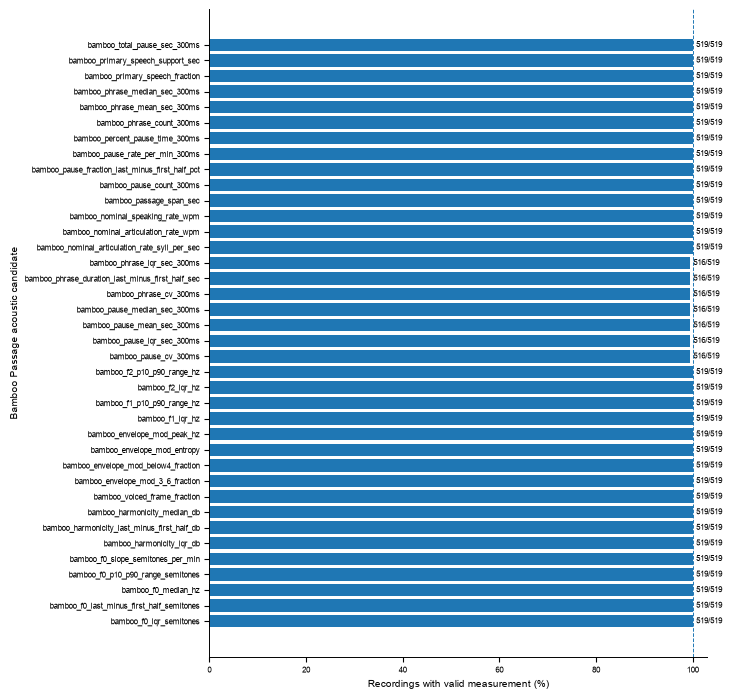

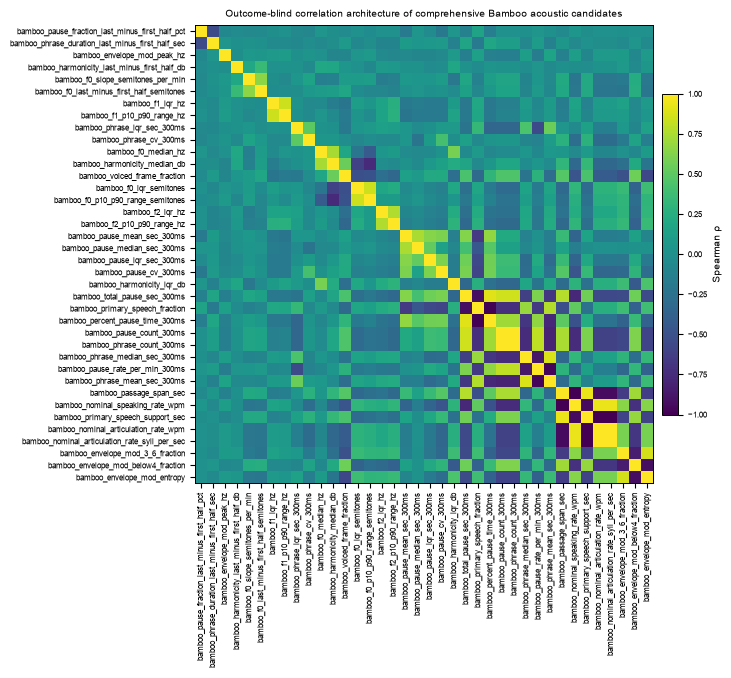

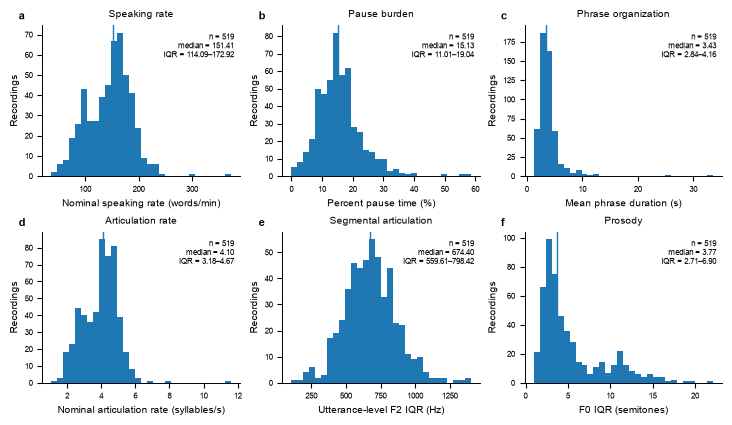

Audit figures: outputs\goal2\acoustic_extraction_v2_1\figures


In [15]:
if RUN_MODE.upper() != "SMOKE":
    MM_TO_IN = 1 / 25.4
    DOUBLE_COLUMN = 183 * MM_TO_IN

    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "axes.linewidth": 0.7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    })

    def clean_axis(ax):
        ax.grid(False)
        ax.spines[
            "top"
        ].set_visible(False)
        ax.spines[
            "right"
        ].set_visible(False)

    def save_figure(
        fig,
        stem,
    ):
        fig.savefig(
            FIGURE_DIR
            / f"{stem}.pdf",
            bbox_inches="tight",
        )

        fig.savefig(
            FIGURE_DIR
            / f"{stem}.svg",
            bbox_inches="tight",
        )

        fig.savefig(
            FIGURE_DIR
            / f"{stem}.png",
            dpi=600,
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

    # ----------------------------------------------------------
    # Availability
    # ----------------------------------------------------------

    plot_table = (
        audit.sort_values(
            [
                "acoustic_family",
                "availability_fraction",
                "feature",
            ]
        )
        .reset_index(drop=True)
    )

    fig_height_mm = max(
        120,
        4.6 * len(plot_table),
    )

    fig, ax = plt.subplots(
        figsize=(
            DOUBLE_COLUMN,
            fig_height_mm
            * MM_TO_IN,
        ),
        constrained_layout=True,
    )

    y = np.arange(
        len(plot_table)
    )

    availability_pct = (
        100
        * plot_table[
            "availability_fraction"
        ]
    )

    ax.barh(
        y,
        availability_pct,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(
        plot_table["feature"]
    )

    ax.axvline(
        100,
        linestyle="--",
        linewidth=0.7,
    )

    ax.set_xlim(
        0,
        103,
    )

    ax.set_xlabel(
        "Recordings with valid measurement (%)"
    )

    ax.set_ylabel(
        "Bamboo Passage acoustic candidate"
    )

    for yy, pct, n in zip(
        y,
        availability_pct,
        plot_table["n_available"],
    ):
        ax.text(
            min(
                float(pct) + 0.7,
                101.3,
            ),
            yy,
            f"{int(n)}/519",
            va="center",
            fontsize=5.5,
        )

    clean_axis(ax)

    save_figure(
        fig,
        "Figure_A_v2_measurement_availability",
    )

    # ----------------------------------------------------------
    # Correlation architecture
    # ----------------------------------------------------------

    corr = (
        acoustic[FEATURES]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .corr(
            method="spearman",
            min_periods=30,
        )
    )

    distance = (
        1.0
        - np.abs(
            corr.fillna(0)
            .to_numpy()
        )
    )

    np.fill_diagonal(
        distance,
        0.0,
    )

    from scipy.cluster import hierarchy
    from scipy.spatial.distance import squareform

    linkage = hierarchy.linkage(
        squareform(
            distance,
            checks=False,
        ),
        method="average",
    )

    order = hierarchy.leaves_list(
        linkage
    )

    ordered_features = [
        corr.columns[i]
        for i in order
    ]

    corr_ordered = corr.loc[
        ordered_features,
        ordered_features,
    ]

    fig, ax = plt.subplots(
        figsize=(
            DOUBLE_COLUMN,
            DOUBLE_COLUMN,
        ),
        constrained_layout=True,
    )

    image = ax.imshow(
        corr_ordered,
        vmin=-1,
        vmax=1,
        aspect="equal",
        interpolation="nearest",
    )

    ax.set_xticks(
        np.arange(
            len(ordered_features)
        )
    )

    ax.set_xticklabels(
        ordered_features,
        rotation=90,
    )

    ax.set_yticks(
        np.arange(
            len(ordered_features)
        )
    )

    ax.set_yticklabels(
        ordered_features
    )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.035,
        pad=0.02,
    )

    colorbar.set_label(
        "Spearman ρ"
    )

    ax.set_title(
        "Outcome-blind correlation architecture "
        "of comprehensive Bamboo acoustic candidates"
    )

    save_figure(
        fig,
        "Figure_B_v2_acoustic_correlation_architecture",
    )

    # ----------------------------------------------------------
    # Representative clinical dashboard
    # ----------------------------------------------------------

    representatives = [
        (
            "bamboo_nominal_speaking_rate_wpm",
            "Speaking rate",
            "Nominal speaking rate (words/min)",
        ),
        (
            "bamboo_percent_pause_time_300ms",
            "Pause burden",
            "Percent pause time (%)",
        ),
        (
            "bamboo_phrase_mean_sec_300ms",
            "Phrase organization",
            "Mean phrase duration (s)",
        ),
        (
            "bamboo_nominal_articulation_rate_syll_per_sec",
            "Articulation rate",
            "Nominal articulation rate (syllables/s)",
        ),
        (
            "bamboo_f2_iqr_hz",
            "Segmental articulation",
            "Utterance-level F2 IQR (Hz)",
        ),
        (
            "bamboo_f0_iqr_semitones",
            "Prosody",
            "F0 IQR (semitones)",
        ),
    ]

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(
            DOUBLE_COLUMN,
            105 * MM_TO_IN,
        ),
        constrained_layout=True,
    )

    for ax, (
        feature,
        title,
        xlabel,
    ) in zip(
        axes.flat,
        representatives,
    ):
        x = pd.to_numeric(
            acoustic[feature],
            errors="coerce",
        )

        x = x[
            np.isfinite(x)
        ]

        ax.hist(
            x,
            bins=30,
        )

        if len(x):
            median = float(
                np.median(x)
            )

            q25, q75 = np.quantile(
                x,
                [.25, .75],
            )

            ax.axvline(
                median,
                linewidth=1.0,
            )

            ax.text(
                0.97,
                0.95,
                f"n = {len(x)}\n"
                f"median = {median:.2f}\n"
                f"IQR = {q25:.2f}–{q75:.2f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=5.7,
            )

        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(
            "Recordings"
        )

        clean_axis(ax)

    for ax, label in zip(
        axes.flat,
        ["a", "b", "c", "d", "e", "f"],
    ):
        ax.text(
            -0.12,
            1.04,
            label,
            transform=ax.transAxes,
            fontsize=8,
            fontweight="bold",
        )

    save_figure(
        fig,
        "Figure_C_v2_Bamboo_clinical_dashboard",
    )

    print(
        "Audit figures:",
        FIGURE_DIR.relative_to(ROOT),
    )


## 15. Reproducibility seal and canonical Goal-2 handoff

The existing v1 canonical files are **not** overwritten until every v2 hard gate passes.

A successful full run atomically promotes the versioned v2 values/registry into the canonical filenames consumed by Notebook 19.


In [16]:
def sha256_file(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        for block in iter(
            lambda: handle.read(
                1024 * 1024
            ),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


def atomic_copy(
    source,
    destination,
):
    source = Path(source)
    destination = Path(destination)

    temporary = destination.with_suffix(
        destination.suffix + ".tmp"
    )

    shutil.copyfile(
        source,
        temporary,
    )

    if (
        not temporary.exists()
        or temporary.stat().st_size == 0
    ):
        raise IOError(
            f"Failed to create valid temporary handoff: {temporary}"
        )

    os.replace(
        temporary,
        destination,
    )


if RUN_MODE.upper() == "SMOKE":
    print(
        "SMOKE COMPLETE — "
        "no canonical Goal-2 handoff was changed."
    )

else:
    acoustic_final = pd.read_csv(
        VALUES_VERSIONED,
        low_memory=False,
    )

    registry_final = pd.read_csv(
        REGISTRY_VERSIONED,
        low_memory=False,
    )

    if len(acoustic_final) != EXPECTED_RECORDINGS:
        raise RuntimeError(
            "Final v2.1 acoustic table is not 519 rows."
        )

    if not acoustic_final[
        "logical_recording_id"
    ].astype(str).is_unique:
        raise RuntimeError(
            "Final v2 acoustic IDs are not unique."
        )

    if (
        acoustic_final[
            "participant_id"
        ].astype(str).nunique()
        != EXPECTED_PARTICIPANTS
    ):
        raise RuntimeError(
            "Final v2.1 participant count is not 224."
        )

    if not registry_final[
        "feature"
    ].is_unique:
        raise RuntimeError(
            "Final v2.1 registry feature IDs are not unique."
        )

    if set(
        registry_final["feature"]
    ) != set(FEATURES):
        raise RuntimeError(
            "Final registry differs from frozen in-memory registry."
        )

    missing_feature_columns = (
        set(
            FEATURES
            + SUPPORT_COLUMNS
        )
        - set(
            acoustic_final.columns
        )
    )

    if missing_feature_columns:
        raise RuntimeError(
            "Final v2 values table is missing: "
            f"{sorted(missing_feature_columns)}"
        )

    # Timing must be available for all retained recordings.
    timing_primary = registry_final.loc[
        (
            registry_final[
                "acoustic_family"
            ].eq("timing_fluency")
        )
        & (
            registry_final[
                "candidate_role"
            ].eq("primary_candidate")
        ),
        "feature",
    ].tolist()

    for feature in timing_primary:
        n_available = int(
            pd.to_numeric(
                acoustic_final[feature],
                errors="coerce",
            )
            .notna()
            .sum()
        )

        # Distributional pause metrics may be legitimately unavailable
        # when no qualifying pause exists. Count/total/percentage/rates
        # and passage-rate measures must be complete.
        always_defined = {
            "bamboo_passage_span_sec",
            "bamboo_pause_count_300ms",
            "bamboo_total_pause_sec_300ms",
            "bamboo_percent_pause_time_300ms",
            "bamboo_nominal_speaking_rate_wpm",
            "bamboo_nominal_articulation_rate_syll_per_sec",
        }

        if (
            feature in always_defined
            and n_available
            != EXPECTED_RECORDINGS
        ):
            raise RuntimeError(
                f"{feature} should be defined for all 519 recordings "
                f"but is available for {n_available}."
            )

    # Require at least some valid articulation support before handoff.
    f2_available = int(
        pd.to_numeric(
            acoustic_final[
                "bamboo_f2_iqr_hz"
            ],
            errors="coerce",
        ).notna().sum()
    )

    if f2_available < 100:
        raise RuntimeError(
            "F2-IQR support is unexpectedly poor "
            f"({f2_available}/519). "
            "Do not freeze A before reviewing the formant estimator."
        )

    # Require no all-missing registered feature.
    all_missing = [
        feature
        for feature in FEATURES
        if (
            pd.to_numeric(
                acoustic_final[
                    feature
                ],
                errors="coerce",
            )
            .notna()
            .sum()
            == 0
        )
    ]

    if all_missing:
        raise RuntimeError(
            "Registered v2.1 features are entirely unavailable: "
            f"{all_missing}"
        )

    package_versions = {}

    for package in [
        "numpy",
        "pandas",
        "scipy",
        "matplotlib",
    ]:
        try:
            package_versions[package] = (
                mdlib.version(package)
            )
        except Exception:
            package_versions[package] = (
                "unavailable"
            )

    manifest = {
        "created_utc": datetime.now(
            timezone.utc
        ).isoformat(),
        "engine_version": ENGINE_VERSION,
        "paper1_decoder_commit": observed_commit,
        "elicitation_task": "Bamboo Passage reading",
        "bamboo_text_sha256": BAMBOO_TEXT_SHA256,
        "bamboo_target_word_count": BAMBOO_WORD_COUNT,
        "bamboo_nominal_syllable_count": BAMBOO_SYLLABLE_COUNT,
        "pause_threshold_sec": MIN_INTERNAL_PAUSE_SEC,
        "retained_recordings": int(
            len(acoustic_final)
        ),
        "participants": int(
            acoustic_final[
                "participant_id"
            ].astype(str).nunique()
        ),
        "n_implemented_candidate_features": int(
            len(FEATURES)
        ),
        "n_deferred_alignment_features": int(
            len(deferred)
        ),
        "n_primary_candidates": int(
            registry_final[
                "candidate_role"
            ].eq(
                "primary_candidate"
            ).sum()
        ),
        "n_extended_candidates": int(
            registry_final[
                "candidate_role"
            ].eq(
                "extended_candidate"
            ).sum()
        ),
        "f2_iqr_available_recordings": f2_available,
        "versioned_values_path": str(
            VALUES_VERSIONED.relative_to(ROOT)
        ),
        "versioned_registry_path": str(
            REGISTRY_VERSIONED.relative_to(ROOT)
        ),
        "deferred_feature_ledger": str(
            DEFERRED_PATH.relative_to(ROOT)
        ),
        "values_sha256": sha256_file(
            VALUES_VERSIONED
        ),
        "registry_sha256": sha256_file(
            REGISTRY_VERSIONED
        ),
        "deferred_sha256": sha256_file(
            DEFERRED_PATH
        ),
        "package_versions": package_versions,
        "feature_selection_used_outcomes": False,
        "feature_selection_used_q_values": False,
        "feature_selection_used_predictive_performance": False,
        "uses_frozen_primary_speech_segmentation": True,
        "uses_canonical_paper1_decoder": True,
        "deliberate_exclusions": [
            "DDK-only measures",
            "sustained-vowel-only jitter/shimmer",
            "raw recorded RMS/intensity as clinical A",
            "QCHAN-like LTAS/centroid/rolloff/high-band/tilt",
            "generic MFCC/embedding banks as Primary-A",
        ],
    }

    RUN_MANIFEST_PATH.write_text(
        json.dumps(
            manifest,
            indent=2,
        ),
        encoding="utf-8",
    )

    # Only now promote v2.1 to canonical Goal-2 inputs.
    atomic_copy(
        VALUES_VERSIONED,
        VALUES_CANONICAL,
    )

    atomic_copy(
        REGISTRY_VERSIONED,
        REGISTRY_CANONICAL,
    )

    print(
        "\nCOMPREHENSIVE BAMBOO "
        "ACOUSTIC EXTRACTION v2: PASS"
    )

    print(
        "Implemented candidates:",
        len(FEATURES),
    )

    print(
        "Deferred alignment-dependent candidates:",
        len(deferred),
    )

    print(
        "F2-IQR support:",
        f"{f2_available}/519",
    )

    print(
        "\nCanonical Goal-2 values:",
        VALUES_CANONICAL.relative_to(ROOT),
    )

    print(
        "Canonical Goal-2 registry:",
        REGISTRY_CANONICAL.relative_to(ROOT),
    )

    print(
        "\nNEXT: run Notebook 19 with "
        "FREEZE_APPROVED = False."
    )

    display(
        pd.DataFrame(
            [manifest]
        ).T.rename(
            columns={0: "value"}
        )
    )



COMPREHENSIVE BAMBOO ACOUSTIC EXTRACTION v2: PASS
Implemented candidates: 38
Deferred alignment-dependent candidates: 6
F2-IQR support: 519/519

Canonical Goal-2 values: data\interim\acoustic_features\bamboo_acoustic_features_recording_level.csv
Canonical Goal-2 registry: data\interim\acoustic_features\bamboo_acoustic_feature_registry.csv

NEXT: run Notebook 19 with FREEZE_APPROVED = False.


,value
created_utc,2026-08-26T20:03:18.674987+00:00
engine_version,bamboo-acoustic-v2.1.0
paper1_decoder_commit,cb31fb6886df1b2b2fedba4ffbbf8624bd56d7e8
elicitation_task,Bamboo Passage reading
bamboo_text_sha256,fa7b35bdf06fa31abd58bddfd552f2f79f18afc05ae1d1...
bamboo_target_word_count,99
bamboo_nominal_syllable_count,137
pause_threshold_sec,0.3
retained_recordings,519
participants,224


## References / rationale used to design the candidate library

The notebook does not select features from the observed clinical data.

The task-level design was informed by published connected-speech/Bamboo work showing:

- Bamboo speaking rate, articulation rate, percent pause time and pause measures are established ALS connected-speech measures.
- Phrase duration and phrase-duration variability are relevant dysarthria/ALS timing constructs.
- Passage-level F2 IQR has been used as a global segmental-articulation measure in dysarthric passage reading.
- ALS Bamboo work has used F2 range from `flower` as an articulatory/tongue-movement proxy.
- Recent Bamboo ALS work extracted /i/, /u/, and /ɑ/ formants and vowel duration to derive VAI and articulatory measures.
- Within-task acoustic variation can occur over a reading passage and should be considered rather than assumed absent.
- Alignment-dependent measures are deferred rather than approximated without word/phone timing.
